# 03 · EDA — Asistente de regalos (Online Retail II)

Este notebook integra los dos análisis exploratorios del equipo en uno solo. Cuando ambos cubrían el mismo tema se conservó el análisis más completo y se unificaron los criterios:

- **Calidad de datos y validación del ETL, categorías, RFM y compras conjuntas** (análisis de Mauricio).
- **Ventas por día y hora, rankings por unidades/ingresos/frecuencia, comparación mayoristas vs. minoristas y elegibilidad de productos** (análisis de Cristian).

**Datos de entrada** (se generan con `python -m src.data.clean`; no se suben al repo):

| Archivo | Variable | Contenido | Se usa para |
|---|---|---|---|
| `online_retail_modelo.parquet` | `df` | 991.648 filas; incluye ventas sin cliente | ventas, productos, países, categorías, compras conjuntas |
| `online_retail_rfm.parquet` | `rfm` | 764.946 filas; solo ventas con `customer_id` | clientes y RFM |
| `catalogo_categorizado.parquet` | `catalogo` | 4.725 productos con su categoría (28 categorías) | secciones B.9 y B.10 |

**Estructura**

- **Parte A — Calidad de datos:** A.0 reconciliación del ETL · A.1 estructura, nulos y duplicados · A.2 cantidades y precios válidos · A.3 `customer_id` faltante · A.4 outliers de cantidad y `factura_bulk` · A.5 integridad temporal · A.6 precios anómalos · A.7 países · A.8 `description` vs. `stock_code` · A.9 decisiones de calidad.
- **Parte B — Hallazgos de negocio:** B.1 estacionalidad · B.2 día y hora · B.3 productos · B.4 precios y cantidades · B.5 facturas · B.6 países · B.7 clientes y RFM · B.8 mayoristas vs. minoristas en los rankings · B.9 categorías · B.10 compras conjuntas.
- **Parte C — Qué significa para el asistente y próximos pasos.**

**Convenciones**

- **Producto = `stock_code`.** La descripción es solo una etiqueta (se usa la más frecuente de cada código). Ver A.8.
- **Ingreso / ventas = `quantity × unit_price`** (columna `ventas` en `df` y `rfm`).
- **"Mayorista" = cliente del 5% que más unidades compró.** Es un proxy de alto volumen, no una etiqueta comercial confirmada. En los datos el valor sigue siendo `mayorista`. Ver A.4.
- **País: `country_std`.** Es `country` con nombres estandarizados (`EIRE` a `Ireland`, `RSA` a `South Africa`, `Unspecified` y `European Community` a `Desconocido`). La columna original `country` no se modifica y se usa en la Parte A, donde se revisan los valores originales; la Parte B usa `country_std` (el filtro por Reino Unido da igual con ambas).
- **Meses completos: diciembre 2009 a noviembre 2011.** Diciembre 2011 solo tiene 9 días y se excluye de las comparaciones mensuales.

**Cómo ejecutarlo:** entorno con `pandas<3` y `pyarrow<22`, kernel apuntando a ese entorno, y *Restart & Run All*. Las salidas guardadas en este archivo provienen de las corridas originales de ambos notebooks sobre los datos reales; al ejecutar todo se regeneran.

In [94]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.options.display.float_format = "{:,.2f}".format
plt.rcParams["figure.figsize"] = (10, 4.5)

PROC = Path("../data/processed")
df = pd.read_parquet(PROC / "online_retail_modelo.parquet")
rfm = pd.read_parquet(PROC / "online_retail_rfm.parquet")

for d in (df, rfm):
    d["ventas"] = d["quantity"] * d["unit_price"]

# País estandarizado para gráficos, tablas y Power BI (la columna original "country" no se modifica)
PAISES_STD = {
    "EIRE": "Ireland",
    "RSA": "South Africa",
    "Unspecified": "Desconocido",
    "European Community": "Desconocido",
}
for d in (df, rfm):
    d["country_std"] = d["country"].replace(PAISES_STD)

print("modelo:", df.shape, "| rfm:", rfm.shape)

modelo: (991648, 12) | rfm: (764946, 12)


# PARTE A — Calidad de datos

Esta parte valida, con evidencia, qué hizo bien `clean.py`, qué particularidades del dataset quedan como están y qué decisiones hay que documentar. No son hallazgos de negocio: son chequeos sobre la calidad del dato.

## A.0 Panorama general y reconciliación del ETL
Antes de revisar cada chequeo, el camino completo: cuántas filas tenía el Excel original, cuántas se fueron en cada filtro y cuántas quedaron en cada archivo final.

In [95]:
print(f"Rango de fechas: {df['invoice_date'].min().date()} a {df['invoice_date'].max().date()}")
print(f"Países distintos: {df['country'].nunique()}")
print(f"Productos distintos: {df['stock_code'].nunique()}")
print(f"Facturas distintas: {df['invoice_no'].nunique()}")

Rango de fechas: 2009-12-01 a 2011-12-09
Países distintos: 43
Productos distintos: 4725
Facturas distintas: 39402


In [96]:
# Esta tabla sale directo del log que imprime pipeline_completo() en clean.py —
# no hay que recalcular nada, solo traerla acá para que quede a la vista en el EDA.

reconciliacion = pd.DataFrame([
    {"paso": "Excel original (2 hojas, con el solapamiento sin sacar)", "filas": 1_067_371},
    {"paso": "Sin solapamiento entre hojas", "filas": 1_044_848},
    {"paso": "Sin compras con cancelación exacta", "filas": 1_043_498},
    {"paso": "Sin cancelaciones", "filas": 1_024_333},
    {"paso": "Cantidad y precio > 0", "filas": 1_018_304},
    {"paso": "Sin códigos no-producto", "filas": 1_013_814},
    {"paso": "Sin duplicados (cantidades sumadas)", "filas": 991_648},
    {"paso": "Sin descripción vacía", "filas": 991_648},
])
reconciliacion["filas_eliminadas_acumuladas"] = reconciliacion["filas"].iloc[0] - reconciliacion["filas"]
reconciliacion["%_eliminado_acumulado"] = (reconciliacion["filas_eliminadas_acumuladas"] / reconciliacion["filas"].iloc[0] * 100).round(2)
reconciliacion

,paso,filas,filas_eliminadas_acumuladas,%_eliminado_acumulado
0,"Excel original (2 hojas, con el solapamiento s...",1067371,0,0.00
1,Sin solapamiento entre hojas,1044848,22523,2.11
2,Sin compras con cancelación exacta,1043498,23873,2.24
3,Sin cancelaciones,1024333,43038,4.03
4,Cantidad y precio > 0,1018304,49067,4.60
5,Sin códigos no-producto,1013814,53557,5.02
6,Sin duplicados (cantidades sumadas),991648,75723,7.09
7,Sin descripción vacía,991648,75723,7.09


**Qué muestra:** del Excel original (1.067.371 filas) se eliminó o consolidó el 7,09% (75.723 filas) hasta llegar al dataset base de 991.648 filas. Los dos pasos más grandes fueron el solapamiento entre hojas del Excel (22.523 filas) y los duplicados, cuyas cantidades se suman en una sola fila (22.166 filas). No son filas descartadas sin razón.

**De ahí salen dos datasets, con objetivos distintos:**
- `online_retail_modelo`: 991.648 filas y 39.402 facturas. No exige cliente, porque el modelo de recomendación necesita saber qué se compra junto con qué, no quién lo compra.
- `online_retail_rfm`: 764.946 filas y 36.480 facturas. Exige cliente, porque RFM necesita atribuir cada compra a un cliente.

*Pendiente opcional:* completar esta tabla con unidades e ingreso del Excel crudo (hay que releer el Excel completo, que es lento).

## A.1 Estructura, nulos y duplicados

In [97]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 991648 entries, 0 to 991647
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   invoice_no    991648 non-null  string        
 1   stock_code    991648 non-null  string        
 2   description   991648 non-null  string        
 3   invoice_date  991648 non-null  datetime64[ns]
 4   unit_price    991648 non-null  float64       
 5   customer_id   764946 non-null  Int64         
 6   country       991648 non-null  string        
 7   quantity      991648 non-null  int64         
 8   segmento      991648 non-null  object        
 9   factura_bulk  991648 non-null  bool          
 10  ventas        991648 non-null  float64       
 11  country_std   991648 non-null  string        
dtypes: Int64(1), bool(1), datetime64[ns](1), float64(2), int64(1), object(1), string(5)
memory usage: 85.1+ MB


,invoice_no,stock_code,description,invoice_date,unit_price,customer_id,country,quantity,segmento,factura_bulk,ventas,country_std
0,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,2009-12-01 07:45:00,1.25,13085,United Kingdom,24,minorista,True,30.00,United Kingdom
1,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,2009-12-01 07:45:00,5.95,13085,United Kingdom,10,minorista,True,59.50,United Kingdom
2,489434,21871,SAVE THE PLANET MUG,2009-12-01 07:45:00,1.25,13085,United Kingdom,24,minorista,True,30.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",2009-12-01 07:45:00,2.10,13085,United Kingdom,48,minorista,True,100.80,United Kingdom
4,489434,22064,PINK DOUGHNUT TRINKET POT,2009-12-01 07:45:00,1.65,13085,United Kingdom,24,minorista,True,39.60,United Kingdom


In [98]:
print(df.isna().sum())
print()
print(df[["quantity", "unit_price", "ventas"]].describe())
print()
print("Rango de fechas:", df["invoice_date"].min(), "->", df["invoice_date"].max())
print("Segmentos (proporción de filas):")
print(df["segmento"].value_counts(normalize=True))
print("Filas en facturas bulk:", f"{df['factura_bulk'].mean():.1%}")

invoice_no           0
stock_code           0
description          0
invoice_date         0
unit_price           0
customer_id     226702
country              0
quantity             0
segmento             0
factura_bulk         0
ventas               0
country_std          0
dtype: int64

        quantity  unit_price     ventas
count 991,648.00  991,648.00 991,648.00
mean       11.10        3.35      19.48
std        68.20        4.72      65.27
min         1.00        0.00       0.00
25%         1.00        1.25       4.16
50%         4.00        2.10      10.14
75%        12.00        4.13      17.70
max    19,152.00    1,157.15  15,818.40

Rango de fechas: 2009-12-01 07:45:00 -> 2011-12-09 12:50:00
Segmentos (proporción de filas):
segmento
minorista     0.54
sin_cliente   0.23
mayorista     0.23
Name: proportion, dtype: float64
Filas en facturas bulk: 5.6%


In [99]:
# Duplicados exactos en df

duplicados = df.duplicated().sum()

print("Filas totales:", len(df))
print("Duplicados exactos:", duplicados)
print("Porcentaje:", f"{duplicados / len(df):.2%}")

Filas totales: 991648
Duplicados exactos: 0
Porcentaje: 0.00%


**Conclusión.** El dataset del modelo no tiene duplicados exactos (0 filas) ni nulos en `invoice_no`, `stock_code`, `description`, `invoice_date`, `unit_price`, `quantity` ni `country`. La única columna con faltantes es `customer_id`: 226.702 filas (22,9%), que se analizan en A.3 porque son un patrón del negocio y no un error de carga. Los filtros de `clean.py` que apuntaban a esto funcionaron como se esperaba.

## A.2 Cantidades y precios válidos

In [100]:
print("Quantity = 0:", (df['quantity'] == 0).sum())
print("Quantity < 0:", (df['quantity'] < 0).sum())
print("Quantity mínima:", df['quantity'].min())

Quantity = 0: 0
Quantity < 0: 0
Quantity mínima: 1


In [101]:
# Precios no positivos
precios_no_positivos = (df['unit_price'] <= 0).sum()

print("Filas con unit_price <= 0:", precios_no_positivos)

print("\nDetalle:")
print(
    df.loc[
        df['unit_price'] <= 0,
        ['invoice_no', 'stock_code', 'description',
         'quantity', 'unit_price', 'customer_id']
    ].head(20)
)

Filas con unit_price <= 0: 0

Detalle:
Empty DataFrame
Columns: [invoice_no, stock_code, description, quantity, unit_price, customer_id]
Index: []


**Conclusión.** Hay 0 filas con cantidad negativa o cero (la cantidad mínima es 1) y 0 filas con precio menor o igual a cero (el precio mínimo es 0,001). Los filtros de `clean.py` para estos dos casos funcionaron. Esto confirma que no quedó ninguna en el dataset final; no dice si existían en el original.

## A.3 `customer_id` faltante: ¿error de carga o patrón real?

In [102]:
# Distribución de registros sin customer_id por país

sin_cliente = (
    df[df['customer_id'].isna()]
    .groupby('country')
    .size()
    .sort_values(ascending=False)
)

print(sin_cliente.head(10))

country
United Kingdom          223939
EIRE                      1556
Hong Kong                  342
Unspecified                223
France                     126
Portugal                   111
Switzerland                104
United Arab Emirates        82
Bahrain                     65
Israel                      46
dtype: int64


In [103]:
# Impacto de los registros sin customer_id

df_tmp = df.assign(
    ingreso=df['quantity'] * df['unit_price']
)

resumen_cliente = (
    df_tmp.groupby(df_tmp['customer_id'].isna())
    .agg(
        filas=('quantity', 'size'),
        unidades=('quantity', 'sum'),
        ingreso=('ingreso', 'sum')
    )
)

resumen_cliente.index = ['Con customer_id', 'Sin customer_id']

print(resumen_cliente)

                  filas  unidades       ingreso
Con customer_id  764946  10317863 16,737,116.61
Sin customer_id  226702    689737  2,577,769.63


In [104]:
# Comparación de operaciones con y sin customer_id

comparacion = (
    df_tmp.groupby(df_tmp['customer_id'].isna())
    .agg(
        cantidad_promedio=('quantity', 'mean'),
        precio_mediano=('unit_price', 'median'),
        ingreso_promedio=('ingreso', 'mean')
    )
)

comparacion.index = ['Con customer_id', 'Sin customer_id']

print(comparacion)

                 cantidad_promedio  precio_mediano  ingreso_promedio
Con customer_id              13.49            1.95             21.88
Sin customer_id               3.04            3.29             11.37


In [105]:
# Facturas que mezclan registros con y sin customer_id

clientes_por_factura = (
    df.assign(
        sin_cliente=df['customer_id'].isna()
    )
    .groupby('invoice_no')['sin_cliente']
    .agg(['any', 'all'])
)

mixtas = clientes_por_factura[
    (clientes_por_factura['any']) &
    (~clientes_por_factura['all'])
]

print("Facturas mixtas:", len(mixtas))

Facturas mixtas: 0


In [106]:
facturas_sin_cliente = (
    df[df['customer_id'].isna()]
    .copy()
)

facturas_sin_cliente['mes'] = (
    facturas_sin_cliente['invoice_date']
    .dt.to_period('M')
)

faltantes_por_mes = (
    facturas_sin_cliente
    .groupby('mes')
    .agg(
        filas=('invoice_no', 'size'),
        facturas=('invoice_no', 'nunique'),
        unidades=('quantity', 'sum'),
        ingreso=('unit_price', lambda x: (
            x * facturas_sin_cliente.loc[x.index, 'quantity']
        ).sum())
    )
    .reset_index()
)

print(faltantes_por_mes.to_string(index=False))

    mes  filas  facturas  unidades    ingreso
2009-12  13111       169     26764 120,254.12
2010-01   8794        90     20554  78,689.52
2010-02   4858        96      9965  40,012.02
2010-03   7962       138     23764  95,799.21
2010-04   5947       120     16095  61,350.68
2010-05   5073       119     10837  50,852.46
2010-06   7612       133     16866  67,879.25
2010-07   5396       145     13148  51,593.56
2010-08   6004       126     19772  79,636.67
2010-09   6414       130     16662  63,767.32
2010-10   8129       136     23475  83,005.83
2010-11  16028       149     72056 273,876.77
2010-12  15255       156     46911 210,517.64
2011-01  13004        98     38624 107,965.77
2011-02   7113       101     17871  65,606.85
2011-03   8551       128     28946 106,703.09
2011-04   6400        96     16545  61,042.88
2011-05   7774       124     22069  80,793.84
2011-06   8695       135     25421  84,444.32
2011-07  11716       131     32244  96,665.84
2011-08   7428        72     23604

In [107]:
productos_por_factura_cliente = (
    df
    .assign(tiene_cliente=df['customer_id'].notna())
    .groupby(['invoice_no', 'tiene_cliente'])
    .agg(
        productos_distintos=('stock_code', 'nunique'),
        lineas=('stock_code', 'size'),
        unidades=('quantity', 'sum')
    )
    .reset_index()
)

resumen_productos_cliente = (
    productos_por_factura_cliente
    .groupby('tiene_cliente')
    .agg(
        facturas=('invoice_no', 'nunique'),
        productos_distintos_promedio=('productos_distintos', 'mean'),
        productos_distintos_mediana=('productos_distintos', 'median'),
        lineas_promedio=('lineas', 'mean'),
        unidades_promedio=('unidades', 'mean')
    )
)

print(resumen_productos_cliente)

               facturas  productos_distintos_promedio  \
tiene_cliente                                           
False              2922                         77.36   
True              36480                         20.97   

               productos_distintos_mediana  lineas_promedio  unidades_promedio  
tiene_cliente                                                                   
False                                19.50            77.58             236.05  
True                                 15.00            20.97             282.84  


**Conclusión.** No es al azar:

- Son el 22,9% de las filas, pero solo el **6,3% de las unidades** (689.737) y el **13,3% del ingreso** (£2,58 M).
- El **98,8% es de Reino Unido** (223.939 de 226.702 filas) y aparecen **en todos los meses**, no en uno puntual.
- **Ninguna factura mezcla** líneas con y sin cliente (0 facturas mixtas).
- Tienen **otro patrón de compra**: facturas con más productos distintos (promedio 77,4 contra 21,0) y menor cantidad promedio por línea (3,0 contra 13,5 unidades).

Es una forma de operar del local y no un error. **Decisión:** se mantienen para ventas, productos, categorías y compras conjuntas, y se excluyen de cualquier análisis centrado en el cliente (RFM).

## A.4 Outliers de cantidad y `factura_bulk`
`factura_bulk` marca facturas que parecen reposición al por mayor: al menos el 80% de sus líneas con cantidad múltiplo de 6 y al menos 5 productos distintos.

In [108]:
# Mayores cantidades registradas en una línea
top_quantity = (
    df
    .nlargest(20, 'quantity')
    [['invoice_no', 'stock_code', 'description',
      'quantity', 'unit_price', 'customer_id',
      'factura_bulk']]
)

top_quantity

,invoice_no,stock_code,description,quantity,unit_price,customer_id,factura_bulk
85774,497946,37410,BLACK AND WHITE PAISLEY FLOWER MUG,19152,0.10,13902,False
120067,501534,21091,SET/6 WOODLAND PAPER PLATES,12960,0.10,13902,True
120069,501534,21099,SET/6 STRAWBERRY PAPER CUPS,12960,0.10,13902,True
120066,501534,21085,SET/6 WOODLAND PAPER CUPS,12744,0.10,13902,True
120068,501534,21092,SET/6 STRAWBERRY PAPER PLATES,12480,0.10,13902,True
308322,521315,17003,BROCADE RING PURSE,11088,0.19,15838,False
127464,502269,21980,PACK OF 12 RED SPOTTY TISSUES,10000,0.25,17940,False
127465,502269,21981,PACK OF 12 WOODLAND TISSUES,10000,0.25,17940,False
127466,502269,21982,PACK OF 12 SUKI TISSUES,10000,0.25,17940,False
127467,502269,21984,PACK OF 12 PINK PAISLEY TISSUES,10000,0.25,17940,False


In [109]:
# Volumen total de unidades por factura
unidades_por_factura = (
    df
    .groupby(['invoice_no', 'factura_bulk'])['quantity']
    .sum()
    .reset_index()
)

print(unidades_por_factura.groupby('factura_bulk')['quantity'].describe())

print("\nPercentiles de unidades por factura:")
print(
    unidades_por_factura
    .groupby('factura_bulk')['quantity']
    .quantile([0.50, 0.75, 0.90, 0.95, 0.99])
)

                 count   mean      std   min    25%    50%    75%       max
factura_bulk                                                               
False        35,582.00 250.58   729.38  1.00  62.00 140.00 275.00 83,774.00
True          3,820.00 547.49 2,607.13 26.00 144.75 249.00 433.00 87,167.00

Percentiles de unidades por factura:
factura_bulk      
False         0.50     140.00
              0.75     275.00
              0.90     493.90
              0.95     728.00
              0.99   1,844.76
True          0.50     249.00
              0.75     433.00
              0.90     865.30
              0.95   1,560.35
              0.99   4,741.36
Name: quantity, dtype: float64


In [110]:
# Facturas con volúmenes extremadamente altos
umbrales = [5000, 10000, 20000]

for umbral in umbrales:
    cantidad = (unidades_por_factura['quantity'] > umbral).sum()
    print(f"Facturas con más de {umbral:,} unidades: {cantidad}")

print("\nDetalle de las 20 facturas con mayor volumen:")
print(
    unidades_por_factura
    .nlargest(20, 'quantity')
)

Facturas con más de 5,000 unidades: 94
Facturas con más de 10,000 unidades: 31
Facturas con más de 20,000 unidades: 8

Detalle de las 20 facturas con mayor volumen:
      invoice_no  factura_bulk  quantity
11926     518505          True     87167
14419     524174          True     87167
3285      497946         False     83774
4701      501534          True     63974
2279      495194          True     63302
5031      502269         False     40000
1759      493819         False     25018
1109      491812          True     20524
8073      509472         False     17766
270       490018         False     17520
17237     530715         False     15696
28501     556917         False     15049
31198     563076         False     14730
36391     574941         False     14149
37038     576365         False     13956
35093     572035         False     13392
18235     533027         False     13387
13112     521315         False     13008
15620     526761         False     12954
2448      49559

In [111]:
facturas_extremas = (
    df.assign(
        ingreso=df['quantity'] * df['unit_price']
    )
    .groupby(['invoice_no', 'factura_bulk'])
    .agg(
        unidades=('quantity', 'sum'),
        productos_distintos=('stock_code', 'nunique'),
        clientes=('customer_id', 'nunique'),
        paises=('country', 'nunique'),
        ingreso=('ingreso', 'sum')
    )
    .reset_index()
)

facturas_extremas = (
    facturas_extremas[
        facturas_extremas['unidades'] > 20_000
    ]
    .sort_values('unidades', ascending=False)
)

print(facturas_extremas)

      invoice_no  factura_bulk  unidades  productos_distintos  clientes  \
11926     518505          True     87167                   45         1   
14419     524174          True     87167                   45         1   
3285      497946         False     83774                   30         1   
4701      501534          True     63974                   10         1   
2279      495194          True     63302                   15         1   
5031      502269         False     40000                    4         1   
1759      493819         False     25018                   94         1   
1109      491812          True     20524                  113         1   

       paises   ingreso  
11926       1 11,880.84  
14419       1 11,880.84  
3285        1 16,973.10  
4701        1  6,866.30  
2279        1  6,989.40  
5031        1 10,000.00  
1759        1 44,051.60  
1109        1 13,854.20  


In [112]:
fact = df.groupby("invoice_no").agg(
    ventas=("ventas", "sum"),
    productos=("stock_code", "nunique"),
    bulk=("factura_bulk", "first"),
)
print("Facturas:", len(fact), "| bulk:", f"{fact['bulk'].mean():.1%}")
print()
print(fact.groupby("bulk")[["ventas", "productos"]].describe().T)

Facturas: 39402 | bulk: 9.7%

bulk                False     True 
ventas    count 35,582.00  3,820.00
          mean     469.31    684.77
          std    1,069.88  1,406.91
          min        0.19     35.28
          25%      144.50    230.31
          50%      294.24    345.95
          75%      474.75    597.39
          max   52,940.94 22,863.36
productos count 35,582.00  3,820.00
          mean      26.29     14.48
          std       44.20     12.20
          min        1.00      5.00
          25%        6.00      7.00
          50%       16.00     11.00
          75%       30.00     18.00
          max    1,107.00    250.00


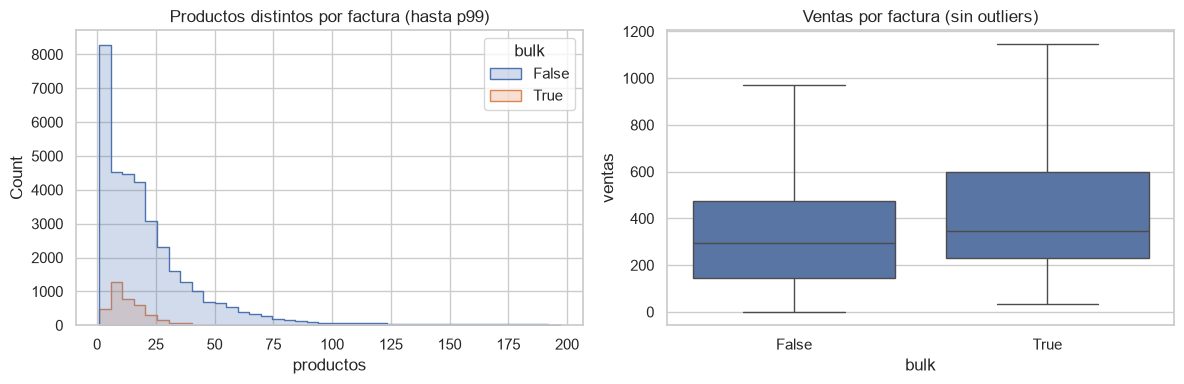

In [113]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=fact[fact["productos"] <= fact["productos"].quantile(.99)],
             x="productos", hue="bulk", bins=40, ax=axes[0], element="step")
axes[0].set_title("Productos distintos por factura (hasta p99)")
sns.boxplot(data=fact, x="bulk", y="ventas", ax=axes[1], showfliers=False)
axes[1].set_title("Ventas por factura (sin outliers)")
plt.tight_layout()
plt.show()

In [114]:
# Comparación de ingresos entre facturas bulk y no bulk
facturas_bulk = (
    df.assign(
        ingreso=lambda x: x['quantity'] * x['unit_price']
    )
    .groupby(['invoice_no', 'factura_bulk'])['ingreso']
    .sum()
    .reset_index()
)

resumen_bulk = (
    facturas_bulk.groupby('factura_bulk')['ingreso']
    .agg(
        ingreso_total='sum',
        ingreso_promedio='mean',
        ingreso_mediano='median',
        cantidad_facturas='count'
    )
)

resumen_bulk['pct_facturas'] = (
    resumen_bulk['cantidad_facturas'] / len(facturas_bulk) * 100
)

resumen_bulk['pct_ingreso'] = (
    resumen_bulk['ingreso_total'] / facturas_bulk['ingreso'].sum() * 100
)

resumen_bulk.round(2)

,ingreso_total,ingreso_promedio,ingreso_mediano,cantidad_facturas,pct_facturas,pct_ingreso
factura_bulk,,,,,,
False,"16,699,051.79",469.31,294.24,35582,90.31,86.46
True,"2,615,834.45",684.77,345.95,3820,9.69,13.54


In [115]:
# Reproduzco el cálculo original de 01_calidad_datos.ipynb, sobre df actual
proporcion_multiplo = (df['quantity'] % 6 == 0).groupby(df['invoice_no']).transform('mean')
n_productos = df.groupby('invoice_no')['stock_code'].transform('nunique')
es_bulk_recalculado = (proporcion_multiplo >= 0.8) & (n_productos >= 5)

facturas_bulk_recalc = df.loc[es_bulk_recalculado, 'invoice_no'].nunique()
print(f"Recalculado ahora: {facturas_bulk_recalc / df['invoice_no'].nunique():.1%}")
print(f"Columna factura_bulk ya guardada: {df[df['factura_bulk']]['invoice_no'].nunique() / df['invoice_no'].nunique():.1%}")

Recalculado ahora: 9.7%
Columna factura_bulk ya guardada: 9.7%


**Conclusión.**

- **Cantidades extremas:** hay líneas de hasta 19.152 unidades. Hay 94 facturas con más de 5.000 unidades, 31 con más de 10.000 y 8 con más de 20.000. Esas 8 tienen un solo cliente, un solo país y entre 4 y 113 productos distintos: son compatibles con pedidos mayoristas reales y no con errores de carga. **No se eliminan.**
- **`factura_bulk` es una heurística útil, no un clasificador perfecto.** La mediana de unidades por factura es 249 en las bulk contra 140 en las demás (percentil 99: 4.741 contra 1.845), pero 3 de las 8 facturas gigantes quedan marcadas `False`. Los dos grupos se superponen.
- **Impacto económico:** las facturas bulk son el 9,69% de las facturas (3.820) y generan el 13,54% del ingreso. Tienen menos productos distintos (mediana 11 contra 16) y un ingreso mediano algo mayor (£345,95 contra £294,24). La diferencia es moderada: las no bulk siguen siendo el 86,46% del ingreso.
- **El 7,1% histórico vs. el 9,7% actual está resuelto.** Recalculado sobre el dataset final da 9,7%, igual que la columna guardada. El 7,1% se midió en un punto intermedio del pipeline, antes de los filtros finales. El número correcto es **9,7% de las facturas**.
- **Dato a confirmar:** las facturas 518505 y 524174 tienen exactamente las mismas unidades (87.167), el mismo número de productos (45) y el mismo ingreso (£11.880,84), con un solo cliente cada una, y comparten líneas idénticas (por ejemplo, 7.128 unidades de SET/6 FRUIT SALAD PAPER CUPS). Puede ser un pedido repetido o una recompra; los datos no permiten saberlo.

### `factura_bulk` no es lo mismo que "cliente mayorista"
- `factura_bulk` describe **una factura puntual**.
- `segmento` describe **al cliente**: si, sumando todas sus compras, está en el 5% que más unidades compró.

Un mayorista puede tener compras chicas que no califican como bulk, y una factura bulk puede venir de un cliente que en el resto de su historial compra como minorista. Además, "mayorista" es una definición estadística (un percentil), no una confirmación de que el cliente revenda. En la documentación conviene llamarlo **segmento de alto volumen (top 5%)** y tratarlo como proxy.

## A.5 Integridad temporal: ¿una factura, una sola fecha?

In [116]:
# ¿Alguna factura tiene más de una fecha distinta entre sus líneas?
fechas_por_factura = df.groupby('invoice_no')['invoice_date'].nunique()
facturas_con_varias_fechas = fechas_por_factura[fechas_por_factura > 1]

print(f"Facturas con más de 1 fecha distinta: {len(facturas_con_varias_fechas)} de {len(fechas_por_factura)}")

# Si hay alguna, miramos qué tan separadas están esas fechas (¿segundos de diferencia, o días?)
if len(facturas_con_varias_fechas) > 0:
    detalle = df[df['invoice_no'].isin(facturas_con_varias_fechas.index)]
    rango_por_factura = detalle.groupby('invoice_no')['invoice_date'].agg(['min', 'max'])
    rango_por_factura['diferencia_minutos'] = (rango_por_factura['max'] - rango_por_factura['min']).dt.total_seconds() / 60
    print(rango_por_factura.sort_values('diferencia_minutos', ascending=False).head(10))

Facturas con más de 1 fecha distinta: 82 de 39402
                           min                 max  diferencia_minutos
invoice_no                                                            
529368     2010-10-28 10:07:00 2010-10-28 10:16:00                9.00
520878     2010-08-31 15:32:00 2010-08-31 15:36:00                4.00
521901     2010-09-09 12:35:00 2010-09-09 12:37:00                2.00
499967     2010-03-03 14:06:00 2010-03-03 14:07:00                1.00
500827     2010-03-10 11:10:00 2010-03-10 11:11:00                1.00
501618     2010-03-18 11:09:00 2010-03-18 11:10:00                1.00
501871     2010-03-21 12:23:00 2010-03-21 12:24:00                1.00
500353     2010-03-07 15:24:00 2010-03-07 15:25:00                1.00
505791     2010-04-26 11:07:00 2010-04-26 11:08:00                1.00
509851     2010-05-26 09:04:00 2010-05-26 09:05:00                1.00


**Conclusión.** 82 de 39.402 facturas (0,2%) tienen más de una fecha entre sus líneas, y la mayor diferencia es de 9 minutos. Es compatible con el tiempo que tarda el sistema en registrar todas las líneas de una compra, y no con un número de factura reutilizado. No hace falta ninguna corrección.

## A.6 Precios anómalos: ¿errores, ajustes o ventas reales?

In [117]:
print(df['unit_price'].describe())

count   991,648.00
mean          3.35
std           4.72
min           0.00
25%           1.25
50%           2.10
75%           4.13
max       1,157.15
Name: unit_price, dtype: float64


In [118]:
precios_extremos = (
    df[
        df['unit_price'] >= 100
    ]
    .groupby(['stock_code', 'description'])
    .agg(
        filas=('unit_price', 'size'),
        precio_min=('unit_price', 'min'),
        precio_max=('unit_price', 'max'),
        unidades=('quantity', 'sum'),
        ingreso=('quantity', lambda x: (x * df.loc[x.index, 'unit_price']).sum())
    )
    .sort_values('precio_max', ascending=False)
)

print(precios_extremos.head(20).to_string())

                                                filas  precio_min  precio_max  unidades   ingreso
stock_code description                                                                           
84016      FLAG OF ST GEORGE CAR FLAG               5      272.27    1,157.15         5  2,986.36
22502      PICNIC BASKET WICKER 60 PIECES           1      649.50      649.50         1    649.50
22655      VINTAGE RED KITCHEN CABINET             48      125.00      295.00        69 12,025.00
22656      VINTAGE BLUE KITCHEN CABINET            35      125.00      295.00        43  9,115.00
22826      LOVE SEAT ANTIQUE WHITE METAL           11      175.00      195.00        12  2,300.00
22827      GIANT SEVENTEEN DRAWER SIDEBOARD         6      145.00      165.00         8  1,240.00
           RUSTIC  SEVENTEEN DRAWER SIDEBOARD      28      145.00      165.00        37  5,745.00
22828      REGENCY MIRROR WITH SHUTTERS            11      145.00      165.00        17  2,565.00
84965B     BLUE KASH

In [119]:
# Impacto de precios potencialmente anómalos para el stock_code 84016

caso_84016 = df[df['stock_code'] == '84016'].copy()

print("Filas:", len(caso_84016))
print("Unidades:", caso_84016['quantity'].sum())
print("Ingreso total:", (caso_84016['quantity'] * caso_84016['unit_price']).sum())
print("Ingreso con precio <= £1:", (
    caso_84016.loc[caso_84016['unit_price'] <= 1, 'quantity'] *
    caso_84016.loc[caso_84016['unit_price'] <= 1, 'unit_price']
).sum())
print("Filas con precio > £1:", (caso_84016['unit_price'] > 1).sum())

Filas: 61
Unidades: 992
Ingreso total: 3786.63
Ingreso con precio <= £1: 391.8
Filas con precio > £1: 11


In [120]:
for sku in ['84016', '22502']:
    print(f"\n{'='*70}")
    print(f"STOCK_CODE: {sku}")
    print('='*70)

    print(
        df[df['stock_code'] == sku]
        .groupby(['description', 'unit_price'])
        .agg(
            filas=('unit_price', 'size'),
            unidades=('quantity', 'sum'),
            ingreso=('quantity', lambda x: (
                x * df.loc[x.index, 'unit_price']
            ).sum())
        )
        .reset_index()
        .sort_values('unit_price', ascending=False)
        .to_string(index=False)
    )


STOCK_CODE: 84016
               description  unit_price  filas  unidades  ingreso
FLAG OF ST GEORGE CAR FLAG    1,157.15      1         1 1,157.15
FLAG OF ST GEORGE CAR FLAG      867.79      1         1   867.79
FLAG OF ST GEORGE CAR FLAG      408.40      1         1   408.40
FLAG OF ST GEORGE CAR FLAG      280.75      1         1   280.75
FLAG OF ST GEORGE CAR FLAG      272.27      1         1   272.27
FLAG OF ST GEORGE CAR FLAG       93.61      2         3   280.83
FLAG OF ST GEORGE CAR FLAG       25.53      3         4   102.12
FLAG OF ST GEORGE CAR FLAG       25.52      1         1    25.52
FLAG OF ST GEORGE CAR FLAG        0.83      2         3     2.49
FLAG OF ST GEORGE CAR FLAG        0.81      1         1     0.81
FLAG OF ST GEORGE CAR FLAG        0.42     46       675   283.50
FLAG OF ST GEORGE CAR FLAG        0.35      1       300   105.00

STOCK_CODE: 22502
                   description  unit_price  filas  unidades  ingreso
PICNIC BASKET WICKER 60 PIECES      649.50      

In [121]:
for sku in ['84016', '22502']:
    print(f"\n{'='*70}")
    print(f"STOCK_CODE: {sku}")
    print('='*70)

    print(
        df[df['stock_code'] == sku]
        .sort_values('unit_price', ascending=False)
        [['invoice_no', 'invoice_date', 'description',
          'quantity', 'unit_price', 'customer_id', 'country']]
        .head(15)
        .to_string(index=False)
    )


STOCK_CODE: 84016
invoice_no        invoice_date                description  quantity  unit_price  customer_id        country
    507637 2010-05-10 14:55:00 FLAG OF ST GEORGE CAR FLAG         1    1,157.15         <NA> United Kingdom
    502451 2010-03-24 14:14:00 FLAG OF ST GEORGE CAR FLAG         1      867.79         <NA> United Kingdom
    506571 2010-04-30 13:04:00 FLAG OF ST GEORGE CAR FLAG         1      408.40         <NA> United Kingdom
    500315 2010-03-07 11:56:00 FLAG OF ST GEORGE CAR FLAG         1      280.75         <NA> United Kingdom
    513439 2010-06-24 14:17:00 FLAG OF ST GEORGE CAR FLAG         1      272.27         <NA> United Kingdom
    502469 2010-03-24 15:39:00 FLAG OF ST GEORGE CAR FLAG         1       93.61         <NA> United Kingdom
    500586 2010-03-09 10:02:00 FLAG OF ST GEORGE CAR FLAG         2       93.61         <NA> United Kingdom
    506393 2010-04-29 13:10:00 FLAG OF ST GEORGE CAR FLAG         1       25.53         <NA> United Kingdom
    50664

In [122]:
# Marco cada fila: ¿su precio es al menos 10 veces su propio precio mediano histórico?
precio_mediano_producto = df.groupby('stock_code')['unit_price'].transform('median')
es_outlier_precio = df['unit_price'] >= (precio_mediano_producto * 10)

tabla = df.groupby(es_outlier_precio)['customer_id'].apply(lambda s: s.isna().mean())
tabla.index = ['Precio normal', 'Precio outlier (10x+)']
print(tabla.apply(lambda x: f"{x:.1%} sin cliente"))
print()
print(f"Total filas outlier de precio: {es_outlier_precio.sum()}")

Precio normal            22.8% sin cliente
Precio outlier (10x+)    99.7% sin cliente
Name: customer_id, dtype: object

Total filas outlier de precio: 756


In [123]:
# 1) Líneas con precio muy distinto del habitual de su propio producto
med = df.groupby("stock_code")["unit_price"].transform("median")
ratio = df["unit_price"] / med
raros = df[(ratio > 10) | (ratio < 0.1)]
print(len(raros), "líneas con precio >10x o <0.1x la mediana de su producto")
raros.assign(mediana=med[raros.index])[["stock_code", "description", "unit_price", "mediana", "quantity"]] \
     .sort_values("unit_price", ascending=False).head(15)

879 líneas con precio >10x o <0.1x la mediana de su producto


,stock_code,description,unit_price,mediana,quantity
181605,84016,FLAG OF ST GEORGE CAR FLAG,"1,157.15",0.42,1
128672,84016,FLAG OF ST GEORGE CAR FLAG,867.79,0.42,1
687292,22502,PICNIC BASKET WICKER 60 PIECES,649.50,5.95,1
171064,84016,FLAG OF ST GEORGE CAR FLAG,408.40,0.42,1
107764,84016,FLAG OF ST GEORGE CAR FLAG,280.75,0.42,1
234465,84016,FLAG OF ST GEORGE CAR FLAG,272.27,0.42,1
128749,84016,FLAG OF ST GEORGE CAR FLAG,93.61,0.42,1
111313,84016,FLAG OF ST GEORGE CAR FLAG,93.61,0.42,2
113322,84033,FLAG OF ST GEORGE,85.10,1.65,1
29622,21262,WHITE GOOSE FEATHER CHRISTMAS TREE,30.39,2.95,1


In [124]:
n_lineas = df.groupby("stock_code")["unit_price"].transform("size")
atipicas = df[((ratio > 10) | (ratio < 0.1)) & (n_lineas >= 5)]
print(len(atipicas), "líneas atípicas (productos con 5 o más ventas)")
print(f"Peso en ventas: {atipicas['ventas'].sum() / df['ventas'].sum():.3%}")
print(f"Por debajo de 0.1x: {(ratio < 0.1).sum()} | por encima de 10x: {(ratio > 10).sum()}")
atipicas["invoice_no"].value_counts().head(10)

876 líneas atípicas (productos con 5 o más ventas)
Peso en ventas: 0.193%
Por debajo de 0.1x: 123 | por encima de 10x: 756


invoice_no
524174    34
518505    34
492425    10
491970     9
497946     8
489857     8
491969     8
489597     8
491966     7
491041     7
Name: count, dtype: Int64

In [125]:
candidatos_precio = [
    '37410', '85160A', '16202A', '16202B',
    '37471', '22499', '84927E', '84033',
    '37444C', '37444A'
]

for sku in candidatos_precio:
    print(f"\n{'='*70}")
    print(f"STOCK_CODE: {sku}")
    print('='*70)

    print(
        df[df['stock_code'] == sku]
        .groupby(['description', 'unit_price'])
        .agg(
            filas=('unit_price', 'size'),
            unidades=('quantity', 'sum'),
            fecha_inicio=('invoice_date', 'min'),
            fecha_fin=('invoice_date', 'max')
        )
        .reset_index()
        .sort_values('unit_price')
        .to_string(index=False)
    )


STOCK_CODE: 37410
                       description  unit_price  filas  unidades        fecha_inicio           fecha_fin
BLACK AND WHITE PAISLEY FLOWER MUG        0.10      2     25164 2010-01-21 15:11:00 2010-02-15 11:57:00
BLACK AND WHITE PAISLEY FLOWER MUG        0.85      3       336 2009-12-01 12:19:00 2010-04-07 14:10:00
BLACK AND WHITE PAISLEY FLOWER MUG        1.06      1        72 2009-12-10 07:43:00 2009-12-10 07:43:00
BLACK AND WHITE PAISLEY FLOWER MUG        1.25     12       113 2009-12-07 11:55:00 2010-03-22 14:30:00
BLACK AND WHITE PAISLEY FLOWER MUG       16.13      4         6 2010-01-25 09:54:00 2010-03-22 13:11:00
BLACK AND WHITE PAISLEY FLOWER MUG       16.48     10        10 2009-12-01 14:44:00 2009-12-22 15:09:00

STOCK_CODE: 85160A
                 description  unit_price  filas  unidades        fecha_inicio           fecha_fin
WHITE BIRD GARDEN DESIGN MUG        0.13      2      8640 2010-08-09 13:10:00 2010-09-27 16:30:00
WHITE BIRD GARDEN DESIGN MUG        1

In [126]:
# Variable formal: ¿esta fila parece un ajuste administrativo, no una venta real?
precio_mediano_producto = df.groupby('stock_code')['unit_price'].transform('median')
es_ajuste_precio = (df['unit_price'] >= precio_mediano_producto * 10) & (df['customer_id'].isna())

print(f"Filas marcadas como posible ajuste: {es_ajuste_precio.sum()} ({es_ajuste_precio.mean():.2%} del dataset)")
print(f"Unidades involucradas: {df.loc[es_ajuste_precio, 'quantity'].sum():,}")
print(f"Ingreso involucrado: £{(df.loc[es_ajuste_precio, 'quantity'] * df.loc[es_ajuste_precio, 'unit_price']).sum():,.2f}")

# ¿Se concentra en pocos códigos, o está repartido?
print("\nTop 10 stock_code con más filas marcadas:")
print(df.loc[es_ajuste_precio, 'stock_code'].value_counts().head(10))

Filas marcadas como posible ajuste: 754 (0.08% del dataset)
Unidades involucradas: 1,050
Ingreso involucrado: £15,393.66

Top 10 stock_code con más filas marcadas:
stock_code
37370    145
40016     45
22945     45
85216     37
22915     31
85217     25
79164     24
21412     23
85175     21
23326     20
Name: count, dtype: Int64


**Conclusión.**

- **Hay precios altos legítimos:** los productos de más de £100 son mayormente muebles (cómodas, aparadores, espejos) que se venden a su precio habitual.
- **Hay precios disparatados respecto del propio producto.** El caso más extremo es el código 84016 (FLAG OF ST GEORGE CAR FLAG): su precio habitual es £0,42 y aparece a £1.157,15, £867,79, £408,40 y otros. Todas esas ventas son de una o dos unidades y sin `customer_id`. El código 22502 es distinto: su precio de £649,50 corresponde a otra descripción ("60 PIECES") que el resto de sus ventas ("SMALL"), por lo que puede ser un producto distinto bajo el mismo código y no un error.
- **Dos análisis independientes coinciden en 756 filas** con precio de al menos 10 veces la mediana de su producto. El **99,7% de ellas no tiene `customer_id`**, contra 22,8% en el resto del dataset. Eso sugiere ajustes administrativos y no ventas reales a precio inflado.
- **Variable formal `es_ajuste_precio`:** precio de al menos 10 veces la mediana del producto **y** sin `customer_id`. Marca **754 filas (0,08% del dataset)**, con 1.050 unidades y £15.393,66 de ingreso. No se concentran en un producto (el código con más casos, 37370, tiene 145 filas). Es una variable calculada en este notebook; todavía no está en `clean.py`.
- **El otro lado del rango (precio menor a 0,1 veces la mediana) tiene otra explicación.** Son 123 líneas, y los casos revisados (por ejemplo, 37410 a £0,10 con 25.164 unidades en total, o 85160A a £0,13 con 8.640) son compatibles con **precios por volumen**, no con errores. Las facturas 518505 y 524174 (las dos de 87.167 unidades de A.4) concentran 34 líneas atípicas cada una; vale revisar si responden a precios por volumen.
- **Peso total:** contando ambos lados, las líneas atípicas de productos con 5 o más ventas son 876 y pesan el 0,19% de las ventas, por lo que es poco probable que cambien los rankings.

**Decisión:** no se eliminan automáticamente. Queda `es_ajuste_precio` para que el equipo decida si se excluye en modelado. No afirmar que son errores sin una validación adicional del negocio.

### A.6.1 Caso particular: PADS, el único producto con precio casi cero
`PADS TO MATCH ALL CUSHIONS` es el único código con precio unitario menor a 0,01 (0,001). Tiene 17 líneas, todas de 1 unidad, y vende 17 unidades por 0,017 de ingreso en total.

In [127]:
print(df[df["unit_price"] < 0.01][["stock_code", "description", "unit_price", "quantity"]]
        .drop_duplicates("stock_code").head(10))
print(df.nlargest(5, "unit_price")[["description", "unit_price", "quantity", "country"]])
print(df.nlargest(5, "quantity")[["description", "unit_price", "quantity", "segmento", "factura_bulk"]])
print(df["segmento"].value_counts(normalize=True))

      stock_code                 description  unit_price  quantity
59176       PADS  PADS TO MATCH ALL CUSHIONS        0.00         1
                           description  unit_price  quantity         country
181605      FLAG OF ST GEORGE CAR FLAG    1,157.15         1  United Kingdom
128672      FLAG OF ST GEORGE CAR FLAG      867.79         1  United Kingdom
687292  PICNIC BASKET WICKER 60 PIECES      649.50         1  United Kingdom
171064      FLAG OF ST GEORGE CAR FLAG      408.40         1  United Kingdom
253144     VINTAGE RED KITCHEN CABINET      295.00         1  United Kingdom
                               description  unit_price  quantity   segmento  \
85774   BLACK AND WHITE PAISLEY FLOWER MUG        0.10     19152  mayorista   
120067         SET/6 WOODLAND PAPER PLATES        0.10     12960  mayorista   
120069         SET/6 STRAWBERRY PAPER CUPS        0.10     12960  mayorista   
120066           SET/6 WOODLAND PAPER CUPS        0.10     12744  mayorista   
120068   

In [128]:
df[df["stock_code"] == "PADS"][["invoice_no", "invoice_date", "unit_price", "quantity"]]

,invoice_no,invoice_date,unit_price,quantity
59176,494914,2010-01-19 17:04:00,0.00,1
70799,496222,2010-01-29 13:53:00,0.00,1
73574,496473,2010-02-01 15:38:00,0.00,1
75547,496643,2010-02-03 11:58:00,0.00,1
85698,497935,2010-02-15 10:47:00,0.00,1
92297,498562,2010-02-21 12:03:00,0.00,1
96029,499056,2010-02-24 13:46:00,0.00,1
98697,499399,2010-02-26 13:26:00,0.00,1
117072,501176,2010-03-15 11:00:00,0.00,1
148103,504332,2010-04-12 16:30:00,0.00,1


**Decisión: conservarlo en los datos.** El ETL mantiene los códigos `GIFT_` y `PADS` a propósito, porque tienen una descripción de producto real, a diferencia de los códigos administrativos que sí se excluyeron. Pesa 0,002% de las filas y no afecta ningún resultado.

**Pendiente para modelado:** 12 clientes minoristas distintos lo compraron (ver B.8.3), así que con un mínimo de 10 clientes no queda excluido. Un producto casi gratuito cabe en cualquier presupuesto; hay que definir con el equipo de modelado si se pone un precio mínimo para poder recomendar.

## A.7 Países: valores que no son países

In [129]:
# 2) Valores de país que no son países
print(sorted(df["country"].unique()))

['Australia', 'Austria', 'Bahrain', 'Belgium', 'Bermuda', 'Brazil', 'Canada', 'Channel Islands', 'Cyprus', 'Czech Republic', 'Denmark', 'EIRE', 'European Community', 'Finland', 'France', 'Germany', 'Greece', 'Hong Kong', 'Iceland', 'Israel', 'Italy', 'Japan', 'Korea', 'Lebanon', 'Lithuania', 'Malta', 'Netherlands', 'Nigeria', 'Norway', 'Poland', 'Portugal', 'RSA', 'Saudi Arabia', 'Singapore', 'Spain', 'Sweden', 'Switzerland', 'Thailand', 'USA', 'United Arab Emirates', 'United Kingdom', 'Unspecified', 'West Indies']


In [130]:
print(df[df["country"].isin(["Unspecified", "European Community"])]
        .groupby("country")["ventas"].agg(["size", "sum"]))

                    size       sum
country                           
European Community    57  1,159.25
Unspecified          739 10,936.01


**Conclusión.** La columna tiene 43 valores. Cuatro no son países estándar: `EIRE` (Irlanda), `RSA` (Sudáfrica), `Unspecified` (739 líneas, £10.936) y `European Community` (57 líneas, £1.159). Estos dos últimos pesan menos del 0,1% de las ventas. No afecta ningún análisis numérico, pero puede afectar a los mapas de Power BI, donde `EIRE`, `RSA` o `Unspecified` pueden no reconocerse como países.

**Decisión:** `EIRE` es el nombre irlandés de Irlanda y `RSA` es Sudáfrica (*Republic of South Africa*). Se agrega la columna **`country_std`** (`EIRE` a `Ireland`, `RSA` a `South Africa`, y los dos dudosos agrupados como `Desconocido`), se conserva la columna original `country` y se usa `country_std` en gráficos, tablas y Power BI (en Power BI, marcarla como categoría de datos *País o región*). `Channel Islands`, `West Indies` y `Korea` se dejan sin cambios.

## A.8 `description` NO es un identificador confiable de producto
Esta es la decisión de calidad que más afecta al resto del análisis y al modelado: cómo se define "producto".

In [131]:
# 3) Productos con más de una descripción
n_desc = df.groupby("stock_code")["description"].nunique()
print((n_desc > 1).sum(), "productos con más de una descripción")

600 productos con más de una descripción


In [132]:
multi = n_desc[n_desc > 1].index[:5]
df[df["stock_code"].isin(multi)].groupby(["stock_code", "description"]).size()

stock_code  description                        
15058A      BLUE POLKADOT GARDEN PARASOL            89
            BLUE WHITE SPOTS GARDEN PARASOL         58
15058B      PINK POLKADOT GARDEN PARASOL           100
            PINK WHITE SPOTS GARDEN PARASOL         56
16012       FOOD/DRINK SPONGE STICKERS              63
            FOOD/DRINK SPUNGE STICKERS              20
16151A      FLOWER DES BLUE HANDBAG/ORANG HANDL      2
            FLOWERS HANDBAG blue and orange          3
16156L      WRAP CAROUSEL                           14
            WRAP, CAROUSEL                          22
dtype: int64

In [133]:
variaciones_producto = (
    df
    .groupby('stock_code')['description']
    .nunique()
    .sort_values(ascending=False)
)

print("Stock codes con más de una descripción:")
print(
    variaciones_producto[
        variaciones_producto > 1
    ].head(30)
)

Stock codes con más de una descripción:
stock_code
22344     4
22346     4
20685     4
22345     4
22384     4
23196     4
23236     4
21524     3
22853     3
22852     3
22536     3
23126     3
21955     3
22197     3
21243     3
22844     3
22333     3
22937     3
22740     3
17107D    3
22356     3
22845     3
23131     3
22191     3
22950     3
22952     3
22383     3
22785     3
22416     3
22139     3
Name: description, dtype: int64


In [134]:
stocks_con_variaciones = variaciones_producto[
    variaciones_producto > 1
].head(10).index

detalle_variaciones = (
    df[df['stock_code'].isin(stocks_con_variaciones)]
    [['stock_code', 'description']]
    .drop_duplicates()
    .sort_values(['stock_code', 'description'])
)

print(detalle_variaciones.to_string(index=False))

stock_code                        description
     20685                  DOOR MAT RED SPOT
     20685              DOORMAT RED RETROSPOT
     20685                   DOORMAT RED SPOT
     20685            RED SPOTTY COIR DOORMAT
     21524    DOOR MAT SPOTTY HOME SWEET HOME
     21524     DOORMAT SPOTTY HOME SWEET HOME
     21524    SPOTTY  HOME SWEET HOME DOORMAT
     22344     PARTY PIZZA DISH PINK POLKADOT
     22344    PARTY PIZZA DISH PINK RETROSPOT
     22344   PARTY PIZZA DISH PINK WHITE SPOT
     22344   PARTY PIZZA DISH PINK+WHITE SPOT
     22345     PARTY PIZZA DISH BLUE POLKADOT
     22345    PARTY PIZZA DISH BLUE RETROSPOT
     22345   PARTY PIZZA DISH BLUE WHITE SPOT
     22345   PARTY PIZZA DISH BLUE+WHITE SPOT
     22346    PARTY PIZZA DISH GREEN POLKADOT
     22346   PARTY PIZZA DISH GREEN RETROSPOT
     22346  PARTY PIZZA DISH GREEN WHITE SPOT
     22346  PARTY PIZZA DISH GREEN+WHITE SPOT
     22384            LUNCH BAG PINK POLKADOT
     22384           LUNCH BAG PIN

In [135]:
stocks_con_varias_desc = variaciones_producto[variaciones_producto > 1].index  # todos los stock_code con 2+ descripciones (fix: la celda original referenciaba una variable que ya no existía)

ingreso_total = (df['quantity'] * df['unit_price']).sum()
unidades_totales = df['quantity'].sum()

filas_afectadas = df[df['stock_code'].isin(stocks_con_varias_desc)]
filas_variaciones = len(filas_afectadas)
unidades_variaciones = filas_afectadas['quantity'].sum()
ingreso_variaciones = (filas_afectadas['quantity'] * filas_afectadas['unit_price']).sum()

print("Filas involucradas:", f"{filas_variaciones:,}")
print("Porcentaje de filas:", f"{filas_variaciones / len(df):.2%}")
print("\nUnidades involucradas:", f"{unidades_variaciones:,.0f}")
print("Porcentaje de unidades:", f"{unidades_variaciones / unidades_totales:.2%}")
print("\nIngreso involucrado:", f"£{ingreso_variaciones:,.2f}")
print("Porcentaje de ingreso:", f"{ingreso_variaciones / ingreso_total:.2%}")

Filas involucradas: 237,319
Porcentaje de filas: 23.93%

Unidades involucradas: 2,673,010
Porcentaje de unidades: 24.28%

Ingreso involucrado: £5,153,409.83
Porcentaje de ingreso: 26.68%


In [136]:
stocks_por_descripcion = (
    df
    .groupby('description')['stock_code']
    .nunique()
    .sort_values(ascending=False)
)

descripciones_varios_stock = stocks_por_descripcion[
    stocks_por_descripcion > 1
]

print("Descripciones asociadas a más de un stock_code:",
      len(descripciones_varios_stock))

print("\nPrimeras 30:")
print(descripciones_varios_stock.head(30))

Descripciones asociadas a más de un stock_code: 38

Primeras 30:
description
COLUMBIAN CANDLE ROUND             4
WHITE BAMBOO RIBS LAMPSHADE        3
COLOURING PENCILS BROWN TUBE       3
MODERN CHRISTMAS TREE CANDLE       3
METAL SIGN,CUPCAKE SINGLE HOOK     3
FAIRY CAKE PLACEMATS               2
BLUE FLOCK GLASS CANDLEHOLDER      2
FRENCH FLORAL CUSHION COVER        2
BLACK SILOUETTE CANDLE PLATE       2
COLUMBIAN CANDLE RECTANGLE         2
BATHROOM METAL SIGN                2
FRENCH PAISLEY CUSHION COVER       2
GINGHAM HEART DECORATION           2
FRENCH LATTICE CUSHION COVER       2
ACRYLIC JEWEL SNOWFLAKE,BLUE       2
EAU DE NILE JEWELLED PHOTOFRAME    2
BROCANTE SHELF WITH HOOKS          2
FROSTED WHITE BASE                 2
HEART T-LIGHT HOLDER               2
PASTEL BLUE PHOTO ALBUM            2
PASTEL PINK PHOTO ALBUM            2
PINK BUTTERFLY CUSHION COVER       2
PINK FAIRY CAKE CUSHION COVER      2
PINK FLOCK GLASS CANDLEHOLDER      2
PINK FLOWERS RABBIT EASTER         

In [137]:
caso_224 = (
    df[
        df['stock_code'].isin(['22432', '22433'])
    ]
    .assign(
        ingreso=lambda x: x['quantity'] * x['unit_price']
    )
    .groupby(['stock_code', 'description'])
    .agg(
        filas=('stock_code', 'size'),
        unidades=('quantity', 'sum'),
        ingreso=('ingreso', 'sum'),
        fecha_inicio=('invoice_date', 'min'),
        fecha_fin=('invoice_date', 'max')
    )
    .reset_index()
)

print(caso_224.to_string(index=False))

stock_code                 description  filas  unidades  ingreso        fecha_inicio           fecha_fin
     22432 WATERING CAN GREEN DINOSAUR      6        48    93.60 2010-02-25 09:21:00 2010-04-19 16:48:00
     22432     WATERING CAN PINK BUNNY    509      3478 6,625.12 2010-02-18 15:19:00 2011-12-08 18:15:00
     22433 WATERING CAN GREEN DINOSAUR    417      2739 5,110.23 2010-02-18 18:33:00 2011-12-08 18:15:00
     22433     WATERING CAN PINK BUNNY      5        54   105.30 2010-02-25 09:21:00 2010-04-19 16:48:00


**Conclusión.** Un mismo `stock_code` puede aparecer con distintas descripciones, y esto afecta a mucho del dataset:

- **600 productos** (12,7% de los 4.725) tienen más de una descripción.
- Esos productos concentran **237.319 filas (23,93%)**, **2.673.010 unidades (24,28%)** y **£5.153.409,83 de ingreso (26,68%)**. Agrupar por descripción en lugar de por código subestimaría cerca de un cuarto del catálogo en cualquier ranking.
- Hay **dos fenómenos mezclados**: (1) cambios reales de nombre, sobre todo alrededor de septiembre-octubre de 2010 (de "SPOT/SPOTTY" a "RETROSPOT/POLKADOT"), además de errores de tipeo (SPONGE/SPUNGE) y diferencias de puntuación; (2) casos puntuales de códigos cruzados, como 22432/22433 ("Watering Can Pink Bunny" y "Green Dinosaur"), concentrados antes de abril de 2010 y compatibles con un error de carga.
- Del otro lado, 38 descripciones están asociadas a más de un `stock_code`; en los ejemplos revisados parecen variantes de color o diseño.

**Decisión:** el identificador de producto es **`stock_code`**, en el EDA y en el modelado. La descripción se usa solo como etiqueta, y se muestra la **más frecuente** de cada código (mismo criterio que `catalogo_productos()` de `clean.py`).

## A.9 Resumen de decisiones de calidad

| # | Hallazgo | Decisión | Estado |
|---|---|---|---|
| 1 | 0 duplicados exactos, 0 nulos en campos clave (salvo `customer_id`), 0 cantidades o precios inválidos | El ETL funcionó como se esperaba | Confirmado |
| 2 | `customer_id` faltante en el 22,9% de las filas | Conservar en el dataset del modelo; excluir de RFM | Decidido |
| 3 | Cantidades extremas (hasta 19.152 unidades en una línea) | Conservar: no hay evidencia de error | Decidido |
| 4 | `factura_bulk` deja 3 de las 8 facturas gigantes sin marcar | Documentar como heurística; evaluar ajustar el criterio | Pendiente |
| 5 | % de facturas bulk: 7,1% histórico contra 9,7% actual | 9,7% es el valor correcto del dataset final | Resuelto |
| 6 | "Mayorista" es el top 5% de clientes por unidades | Llamarlo "segmento de alto volumen (top 5%)"; es un proxy | Decidido |
| 7 | 754 filas con precio de 10 veces la mediana o más y sin cliente (`es_ajuste_precio`) | Marcar sin eliminar; decidir si se excluyen en modelado | Parcial |
| 8 | Precios por debajo de 0,1 veces la mediana (123 líneas) | Compatibles con precios por volumen; conservar | Decidido |
| 9 | PADS: precio de 0,001 | Conservar en los datos; definir precio mínimo para recomendar | Pendiente (modelado) |
| 10 | `description` no es identificador (23,93% de las filas afectadas) | Usar siempre `stock_code`, con la descripción más frecuente como etiqueta | Decidido |
| 11 | Países no estándar (`EIRE`, `RSA`, `Unspecified`, `European Community`) | Columna nueva `country_std`; `country` queda intacta | Decidido |
| 12 | Facturas 518505 y 524174 idénticas en unidades, productos e ingreso | Confirmar si es un pedido repetido | Pendiente |
| 13 | Mayoristas y ventas sin cliente en el entrenamiento y la recomendación | Decisión del equipo (ver B.8) | Pendiente |

# PARTE B — Hallazgos de negocio

## B.1 Estacionalidad: unidades, ingresos y ticket
Diciembre 2011 solo tiene 9 días de datos y se excluye de los gráficos mensuales: compararlo con un mes completo da un falso desplome.

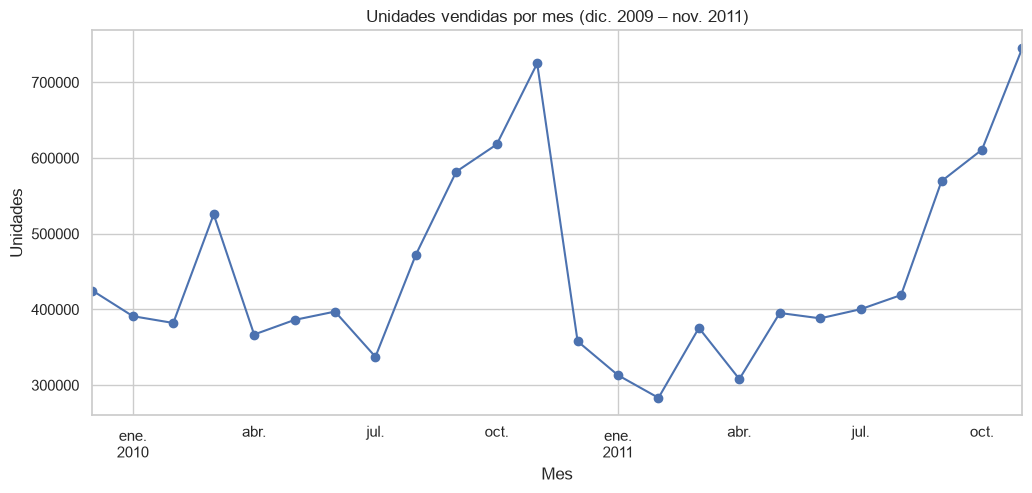

In [138]:
ventas_por_mes = df.set_index('invoice_date').resample('ME')['quantity'].sum()
ventas_por_mes_completos = ventas_por_mes.iloc[:-1]  # saco diciembre 2011: solo 9 días de datos, no un mes completo

plt.figure(figsize=(12, 5))
ventas_por_mes_completos.plot(kind='line', marker='o')
plt.title('Unidades vendidas por mes (dic. 2009 – nov. 2011)')
plt.xlabel('Mes')
plt.ylabel('Unidades')
plt.show()

In [139]:
print("Los 3 meses con más unidades vendidas:")
print(ventas_por_mes_completos.sort_values(ascending=False).head(3))
print()
print("Los 3 meses con menos unidades vendidas:")
print(ventas_por_mes_completos.sort_values().head(3))

Los 3 meses con más unidades vendidas:
invoice_date
2011-11-30    745545
2010-11-30    724991
2010-10-31    618004
Name: quantity, dtype: int64

Los 3 meses con menos unidades vendidas:
invoice_date
2011-02-28    283210
2011-04-30    308014
2011-01-31    313093
Name: quantity, dtype: int64


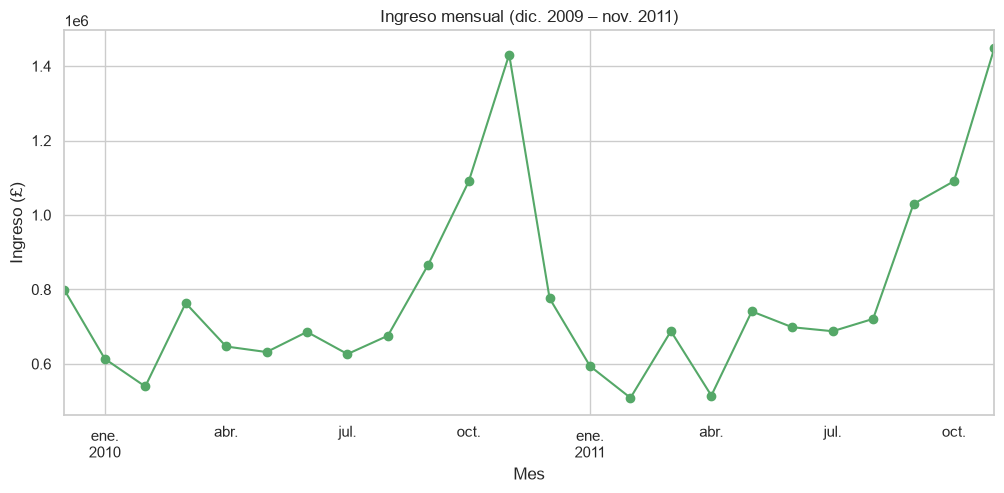

In [140]:
df_modelo_ingreso_mes = df.copy()
df_modelo_ingreso_mes['ingreso'] = df_modelo_ingreso_mes['quantity'] * df_modelo_ingreso_mes['unit_price']
ingreso_por_mes = df_modelo_ingreso_mes.set_index('invoice_date').resample('ME')['ingreso'].sum().iloc[:-1]  # saco el mes incompleto, mismo criterio de la Sección 2.1

plt.figure(figsize=(12, 5))
ingreso_por_mes.plot(kind='line', marker='o', color='#55A868')
plt.title('Ingreso mensual (dic. 2009 – nov. 2011)')
plt.xlabel('Mes')
plt.ylabel('Ingreso (£)')
plt.show()

In [141]:
print("Ingreso por mes:")
print(ingreso_por_mes)
print()
print("Ticket promedio por mes (ingreso / unidades):")
ventas_por_mes_unidades = df.set_index('invoice_date').resample('ME')['quantity'].sum().iloc[:-1]
print((ingreso_por_mes / ventas_por_mes_unidades).round(2))

Ingreso por mes:
invoice_date
2009-12-31     798,617.07
2010-01-31     613,595.26
2010-02-28     539,296.21
2010-03-31     763,258.12
2010-04-30     646,758.62
2010-05-31     631,819.54
2010-06-30     685,977.06
2010-07-31     626,440.52
2010-08-31     675,659.08
2010-09-30     866,858.51
2010-10-31   1,090,076.47
2010-11-30   1,430,959.73
2010-12-31     775,968.38
2011-01-31     593,976.11
2011-02-28     508,790.30
2011-03-31     687,851.91
2011-04-30     514,872.16
2011-05-31     741,093.96
2011-06-30     698,520.21
2011-07-31     687,751.55
2011-08-31     720,874.69
2011-09-30   1,029,566.79
2011-10-31   1,090,777.99
2011-11-30   1,448,903.95
Freq: ME, Name: ingreso, dtype: float64

Ticket promedio por mes (ingreso / unidades):
invoice_date
2009-12-31   1.88
2010-01-31   1.57
2010-02-28   1.41
2010-03-31   1.45
2010-04-30   1.76
2010-05-31   1.64
2010-06-30   1.73
2010-07-31   1.86
2010-08-31   1.43
2010-09-30   1.49
2010-10-31   1.76
2010-11-30   1.97
2010-12-31   2.17
2011-01-31  

In [142]:
# Ingreso total por factura
ingreso_por_factura = (
    df.assign(
        ingreso=lambda x: x['quantity'] * x['unit_price']
    )
    .groupby('invoice_no')['ingreso']
    .sum()
)

print(ingreso_por_factura.describe())

print("\nPercentiles:")
print(
    ingreso_por_factura.quantile(
        [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

count   39,402.00
mean       490.20
std      1,108.87
min          0.19
25%        151.38
50%        301.72
75%        485.98
max     52,940.94
Name: ingreso, dtype: float64

Percentiles:
0.25     151.38
0.50     301.72
0.75     485.98
0.90     905.64
0.95   1,429.90
0.99   4,071.92
Name: ingreso, dtype: float64


**Conclusión.**

- **Noviembre es el mes más fuerte en los dos años.** En unidades: noviembre 2011 (745.545) y noviembre 2010 (724.991) son el primero y el segundo mes de mayor venta, y octubre 2010 es el tercero (618.004). Los más flojos son febrero 2011 (283.210), abril 2011 y enero 2011; febrero vende menos de la mitad que noviembre.
- **En ingresos pasa lo mismo y se ve la subida desde septiembre:** noviembre 2010 £1.430.960 y noviembre 2011 £1.448.904. Septiembre y octubre ya están por encima del nivel del resto del año (octubre 2010 y octubre 2011 casi coinciden, en £1,09 M). Es consistente con compras de regalo adelantadas antes de las fiestas.
- **Hay crecimiento de un año al otro, pero no parejo.** Septiembre 2011 (£1.029.567) supera a septiembre 2010 (£866.859) en un 19%; febrero y abril 2011 quedan por debajo de sus equivalentes de 2010.
- **Cuidado con el nombre de la cuenta "ingreso ÷ unidades":** no es el ticket, es el **precio medio por unidad vendida**. Sube en temporada de fiestas: diciembre 2010 tiene el más alto (£2,17), seguido de noviembre (~£1,95).
- **El ticket real se calcula por factura:** el promedio es £490,20 y la mediana £301,72. La diferencia indica una cola de facturas grandes (percentil 95: £1.430; percentil 99: £4.072; máximo: £52.940,94). Por eso conviene describir el comportamiento con medianas y no solo con promedios.

## B.2 Día de la semana y hora

invoice_date
Monday       2010765
Tuesday      2063771
Wednesday    1996709
Thursday     2302660
Friday       1594769
Saturday        5119
Sunday       1033807
Name: quantity, dtype: int64


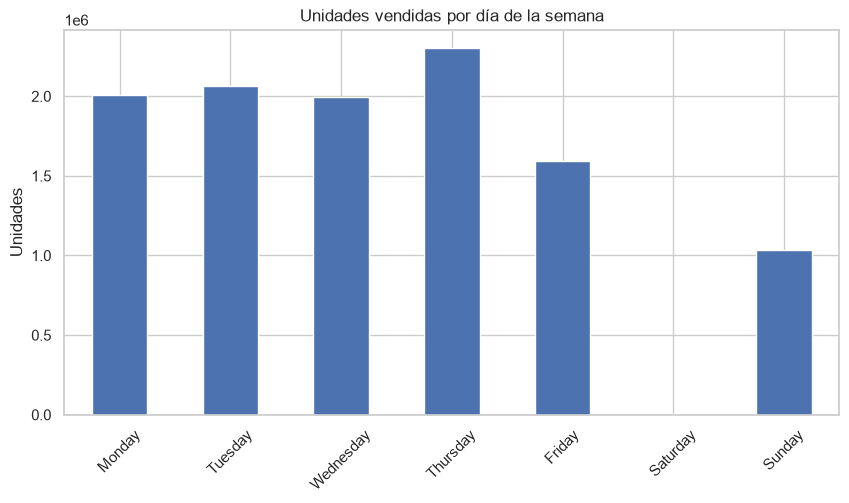

In [143]:
ventas_por_dia = df.groupby(df['invoice_date'].dt.day_name())['quantity'].sum()  # sumo unidades por nombre de día

orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ventas_por_dia = ventas_por_dia.reindex(orden_dias)  # reordeno de lunes a domingo, no alfabético
print(ventas_por_dia)

plt.figure(figsize=(10, 5))
ventas_por_dia.plot(kind='bar', color='#4C72B0')
plt.title('Unidades vendidas por día de la semana')
plt.xlabel('')
plt.ylabel('Unidades')
plt.xticks(rotation=45)
plt.show()

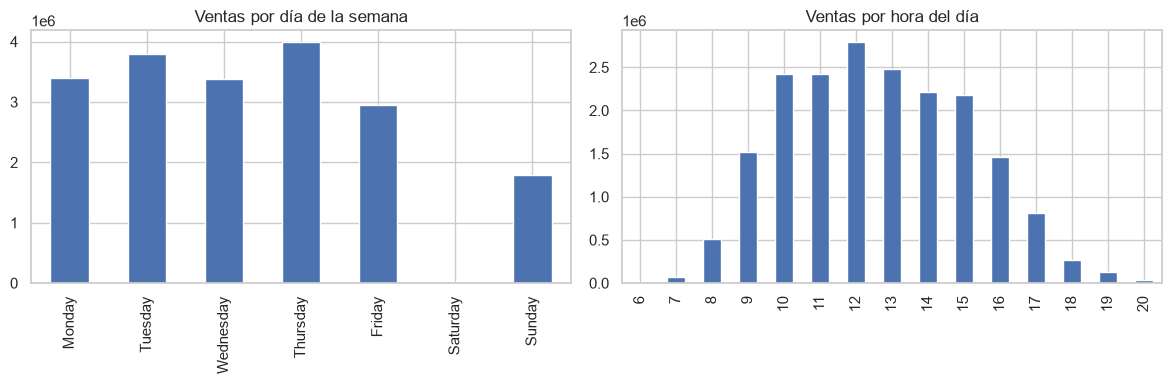

In [144]:
orden = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
por_dia = df.groupby(df["invoice_date"].dt.day_name())["ventas"].sum().reindex(orden)
por_hora = df.groupby(df["invoice_date"].dt.hour)["ventas"].sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
por_dia.plot.bar(ax=axes[0], title="Ventas por día de la semana")
por_hora.plot.bar(ax=axes[1], title="Ventas por hora del día")
for a in axes:
    a.set_xlabel("")
plt.tight_layout()
plt.show()

**Conclusión.**

- **Los sábados casi no hay actividad:** 5.119 unidades, contra más de 2 millones en los días fuertes (lunes a miércoles rondan los 2 millones y el jueves es el pico, con 2.302.660). El viernes baja a 1,59 millones y el domingo es el día más flojo con actividad (1.033.807).
- **Por hora:** las ventas se concentran entre las 10 y las 15, con el máximo a las 12.
- **Lo que no se puede afirmar:** que sea un negocio B2B. Es una explicación razonable, pero los datos solo muestran que prácticamente no se opera los sábados, compatible con un negocio mayormente entre semana. La causa exacta no se puede demostrar con estos números.

## B.3 Productos más vendidos: unidades contra ingresos
Los productos se identifican por `stock_code` y se muestran con su descripción más frecuente (ver A.8).

Productos distintos: 4725


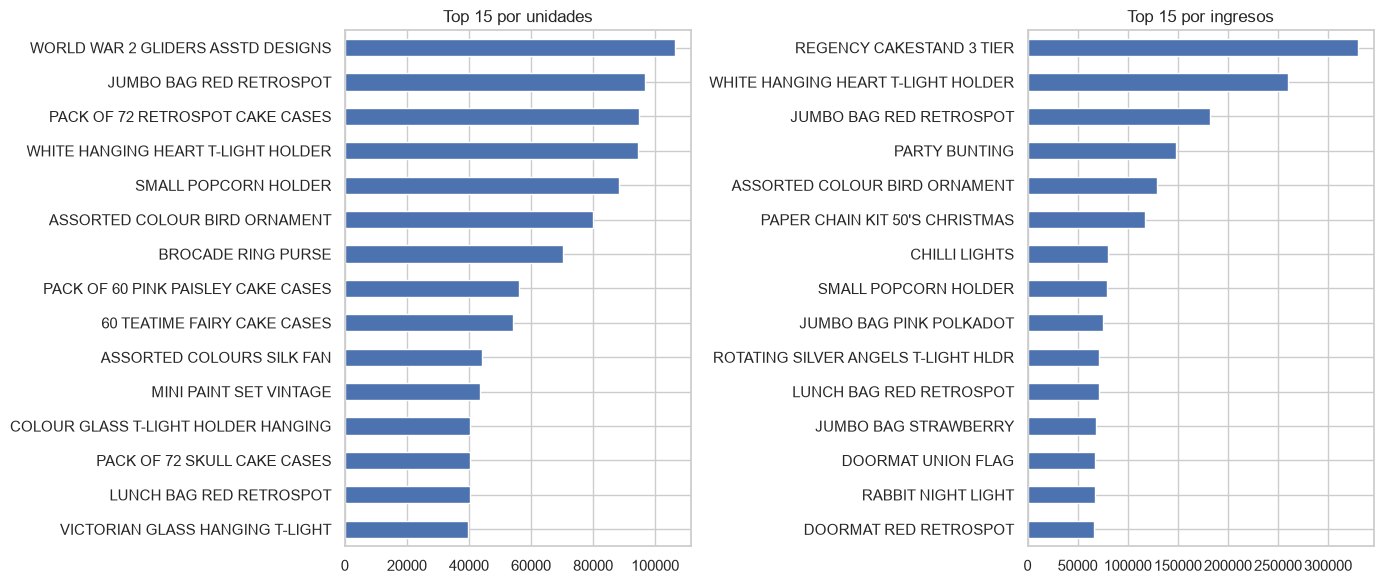

In [145]:
# Descripción más frecuente de cada código (el mismo producto puede tener varias descripciones)
desc = (df.groupby(["stock_code", "description"]).size().reset_index(name="n")
          .sort_values("n", ascending=False).drop_duplicates("stock_code")
          .set_index("stock_code")["description"])

prod = df.groupby("stock_code").agg(unidades=("quantity", "sum"), ventas=("ventas", "sum"),
                                    precio_mediana=("unit_price", "median"))
prod["descripcion"] = desc
print("Productos distintos:", len(prod))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
prod.nlargest(15, "unidades").set_index("descripcion")["unidades"].sort_values().plot.barh(
    ax=axes[0], title="Top 15 por unidades")
prod.nlargest(15, "ventas").set_index("descripcion")["ventas"].sort_values().plot.barh(
    ax=axes[1], title="Top 15 por ingresos")
for a in axes:
    a.set_ylabel("")
plt.tight_layout()
plt.show()

**Conclusión.** Hay 4.725 productos distintos y los dos rankings cuentan historias distintas:

- **Por unidades** lidera WORLD WAR 2 GLIDERS ASSTD DESIGNS (106.331 unidades), seguido de JUMBO BAG RED RETROSPOT, PACK OF 72 RETROSPOT CAKE CASES y WHITE HANGING HEART T-LIGHT HOLDER. Dominan artículos baratos y de pack.
- **Por ingresos** lidera REGENCY CAKESTAND 3 TIER (£329.342), seguido de WHITE HANGING HEART T-LIGHT HOLDER (£260.414), JUMBO BAG RED RETROSPOT (£181.639) y PARTY BUNTING (£148.376).
- El producto líder en unidades **no entra en el top 15 por ingresos**, y el líder en ingresos no aparece entre los de mayor volumen: el precio unitario cambia el aporte económico de cada producto.

Esto importa para el asistente: la popularidad por unidades y la contribución a la facturación son señales distintas, y las recomendaciones no deberían basarse en una sola. Ver B.8 para el efecto de los mayoristas.

## B.4 Precios y cantidades

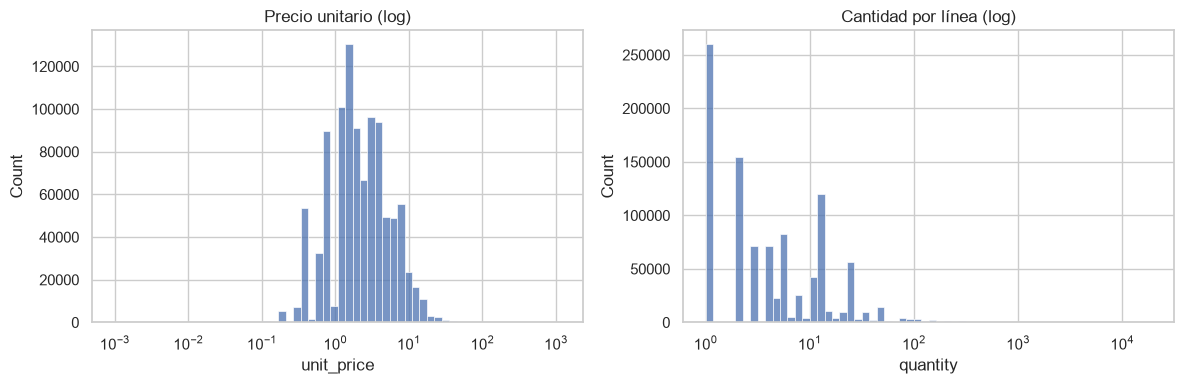

      unit_price  quantity
0.50        2.10      4.00
0.75        4.13     12.00
0.90        7.65     24.00
0.95        9.95     32.00
0.99       16.95    108.00
1.00       34.95    500.00


In [146]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["unit_price"], log_scale=True, bins=60, ax=axes[0])
axes[0].set_title("Precio unitario (log)")
sns.histplot(df["quantity"], log_scale=True, bins=60, ax=axes[1])
axes[1].set_title("Cantidad por línea (log)")
plt.tight_layout()
plt.show()

print(df[["unit_price", "quantity"]].quantile([.5, .75, .9, .95, .99, .999]))

count   4,725.00
mean        3.93
std         8.41
min         0.00
25%         1.25
50%         2.10
75%         4.25
max       295.00
Name: unit_price, dtype: float64


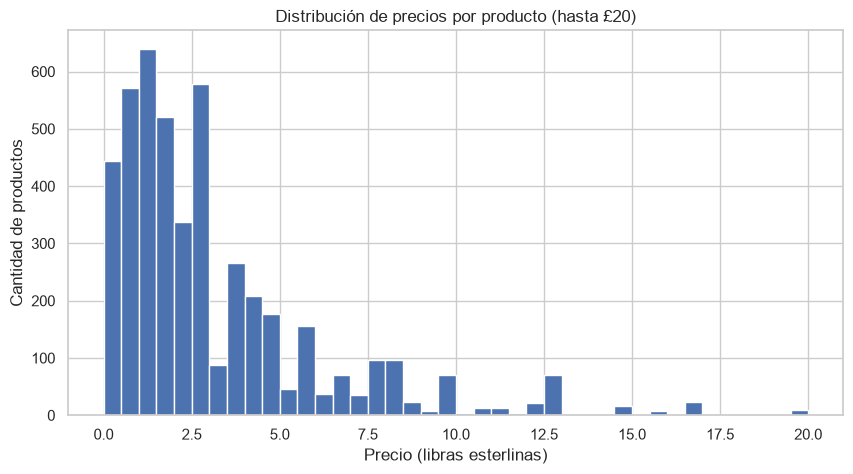

In [147]:
precio_por_producto = df.groupby('stock_code')['unit_price'].median()  # precio típico de cada producto (mediana, no promedio)
print(precio_por_producto.describe())

plt.figure(figsize=(10, 5))
precio_por_producto[precio_por_producto <= 20].hist(bins=40, color='#4C72B0')  # recorto en 20 libras para que los pocos productos carísimos no aplasten el gráfico
plt.title('Distribución de precios por producto (hasta £20)')
plt.xlabel('Precio (libras esterlinas)')
plt.ylabel('Cantidad de productos')
plt.show()

In [148]:
print(precio_por_producto.sort_values(ascending=False).head(5))

stock_code
22656   295.00
22827   165.00
22828   145.00
85070   125.00
22655   125.00
Name: unit_price, dtype: float64


In [149]:
codigos_caros = precio_por_producto.sort_values(ascending=False).head(5).index
display(df[df['stock_code'].isin(codigos_caros)][['stock_code', 'description']].drop_duplicates())

,stock_code,description
187931,85070,ANT WHITE SWEETHEART TABLE W 3 DRAW
253144,22655,VINTAGE RED KITCHEN CABINET
253145,22656,VINTAGE BLUE KITCHEN CABINET
383735,22827,GIANT SEVENTEEN DRAWER SIDEBOARD
384359,22828,REGENCY MIRROR WITH SHUTTERS
400473,22827,RUSTIC SEVENTEEN DRAWER SIDEBOARD


**Conclusión.**

- **Por línea de venta:** el precio mediano es £2,10 (percentil 99: £16,95) y la cantidad mediana es 4 unidades (percentil 99: 108). Ambas variables tienen cola larga, así que conviene usar medianas y escala logarítmica.
- **Por producto (precio mediano de cada código):** la mediana del catálogo es £2,10 y el 75% de los productos cuesta £4,25 o menos. La gran mayoría son regalos económicos.
- **Los cinco productos más caros son muebles** (VINTAGE KITCHEN CABINET, GIANT SEVENTEEN DRAWER SIDEBOARD, REGENCY MIRROR WITH SHUTTERS, ANT WHITE SWEETHEART TABLE), con precios de £125 a £295. Estiran el rango, pero son una minoría muy distinta del resto del catálogo.

## B.5 Facturas: tamaño y peso económico

count   39,402.00
mean        25.15
std         42.32
min          1.00
25%          6.00
50%         15.00
75%         28.75
max      1,107.00
Name: stock_code, dtype: float64


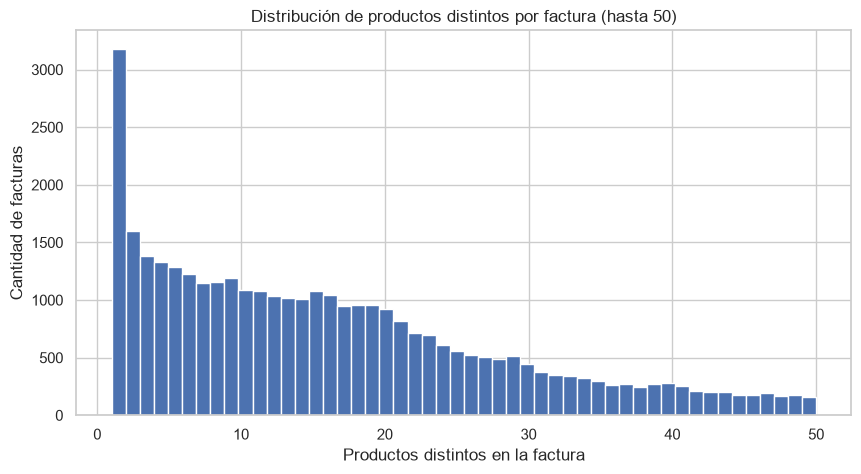

In [150]:
productos_por_factura = df.groupby('invoice_no')['stock_code'].nunique()  # cuántos productos DISTINTOS tiene cada factura
print(productos_por_factura.describe())

plt.figure(figsize=(10, 5))
productos_por_factura[productos_por_factura <= 50].hist(bins=50, color='#4C72B0')  # recorto en 50 para que los pocos casos extremos no aplasten el gráfico
plt.title('Distribución de productos distintos por factura (hasta 50)')
plt.xlabel('Productos distintos en la factura')
plt.ylabel('Cantidad de facturas')
plt.show()

**Conclusión.** La mediana es de 15 productos distintos por factura, pero el promedio es 25,1 porque hay facturas muy grandes (hasta 1.107 productos). El 25% de las facturas tiene 6 productos o menos, y el histograma muestra su pico en las facturas de un solo producto (alrededor de 3.200 facturas). Conviven dos patrones de compra: compras puntuales de pocos artículos y compras grandes, probablemente ligadas a las facturas bulk (A.4). Para el asistente, esto plantea si debe sugerir productos individuales, combos o ambos según el perfil de la compra.

## B.6 Países

Reino Unido: 85.3% de las ventas


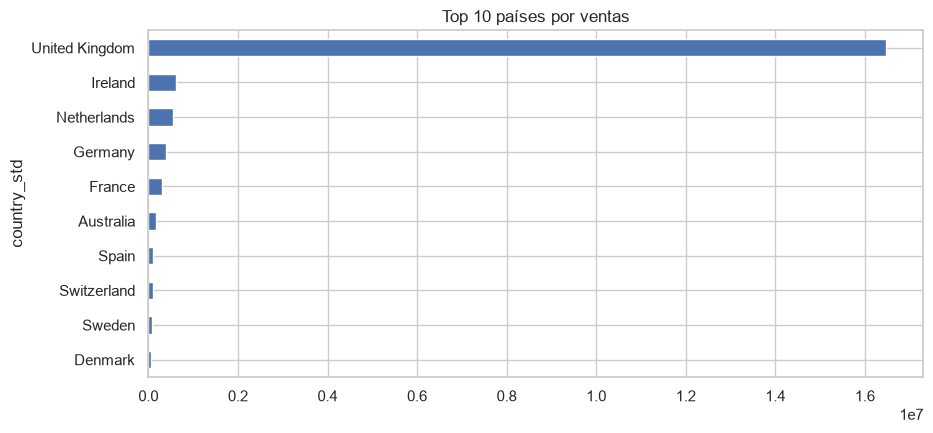

Sin Reino Unido:


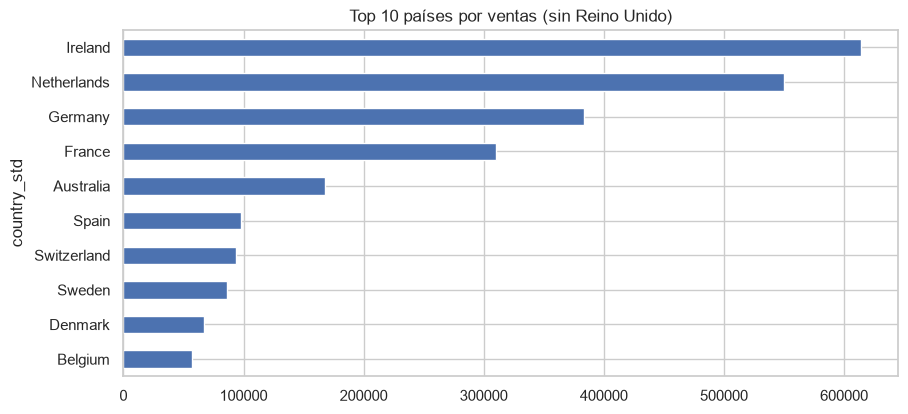

In [151]:
pais = df.groupby("country_std")["ventas"].sum().sort_values(ascending=False)
print(f"Reino Unido: {pais.get('United Kingdom', 0) / pais.sum():.1%} de las ventas")
pais.head(10).sort_values().plot.barh(title="Top 10 países por ventas")
plt.show()

print("Sin Reino Unido:")
pais.drop("United Kingdom", errors="ignore").head(10).sort_values().plot.barh(
    title="Top 10 países por ventas (sin Reino Unido)")
plt.show()

In [152]:
cantidad_promedio_uk = df[df['country'] == 'United Kingdom']['quantity'].mean()
cantidad_promedio_resto = df[df['country'] != 'United Kingdom']['quantity'].mean()

print(f"Cantidad promedio por línea, UK: {cantidad_promedio_uk:.1f}")
print(f"Cantidad promedio por línea, resto del mundo: {cantidad_promedio_resto:.1f}")

Cantidad promedio por línea, UK: 9.9
Cantidad promedio por línea, resto del mundo: 25.3


In [153]:
pais_por_segmento = rfm.groupby(['country_std', 'segmento']).size().unstack(fill_value=0)
pais_por_segmento['total'] = pais_por_segmento.sum(axis=1)
pais_por_segmento['%_mayorista'] = pais_por_segmento.get('mayorista', 0) / pais_por_segmento['total']

print(pais_por_segmento.sort_values('%_mayorista', ascending=False).head(10)[['mayorista', 'minorista', '%_mayorista']])

segmento     mayorista  minorista  %_mayorista
country_std                                   
Singapore          332          0         1.00
Ireland          15288          0         1.00
Netherlands       3817       1159         0.77
Japan              293        139         0.68
Australia          865        856         0.50
France            5987       6950         0.46
Germany           7040       8734         0.45
Norway             559        704         0.44
Sweden             490        777         0.39
Switzerland       1068       1882         0.36


In [154]:
# Cuántos clientes hay detrás de cada porcentaje de mayoristas por país
clientes_por_pais = rfm.groupby(["country_std", "segmento"])["customer_id"].nunique().unstack(fill_value=0)
clientes_por_pais.reindex(["Ireland", "Singapore", "Netherlands", "Japan", "Australia"])

segmento,mayorista,minorista
country_std,,
Ireland,3,0
Singapore,1,0
Netherlands,1,21
Japan,3,7
Australia,1,14


**Conclusión.**

- **Reino Unido concentra el 85,3% de las ventas** y el 81,8% de las unidades. Sin contar Reino Unido, los principales mercados por ingreso son Irlanda (`EIRE` en los datos originales), Países Bajos, Alemania, Francia y Australia.
- **Fuera de Reino Unido se compra más por línea:** 25,3 unidades promedio contra 9,9. Puede deberse a unos pocos clientes de alto volumen (ver el punto siguiente).
- **La proporción de mayoristas por país depende de muy pocos clientes** (datos de clientes con identificación). Irlanda y Singapur aparecen con el 100% de sus líneas en el segmento mayorista, pero detrás hay solo 3 y 1 clientes, y ningún minorista. Países Bajos (77% de las líneas) tiene 1 cliente mayorista contra 21 minoristas, Australia (50%) 1 contra 14 y Japón (68%) 3 contra 7. Un solo cliente de alto volumen explica la mayor parte de las líneas de Países Bajos y la mitad de las de Australia. No hay evidencia de que un mercado sea "de alto volumen" como patrón: son casos individuales.

## B.7 Clientes: concentración, frecuencia y RFM
Se usa el dataset `rfm` (solo ventas con cliente identificado).

In [155]:
cli = rfm.groupby("customer_id").agg(
    ventas=("ventas", "sum"), unidades=("quantity", "sum"),
    facturas=("invoice_no", "nunique"), segmento=("segmento", "first"))
print("Clientes:", len(cli))
print(cli["segmento"].value_counts())
print()
print(cli.groupby("segmento")[["ventas", "unidades", "facturas"]].agg(["median", "sum"]))

Clientes: 5850
segmento
minorista    5557
mayorista     293
Name: count, dtype: int64

             ventas              unidades          facturas       
             median          sum   median      sum   median    sum
segmento                                                          
mayorista 14,070.25 8,328,338.01 8,534.00  5521180    25.00  10455
minorista    788.01 8,408,778.59   446.00  4796683     3.00  26025


segmento
mayorista    5521180
minorista    4796683
Name: quantity, dtype: int64


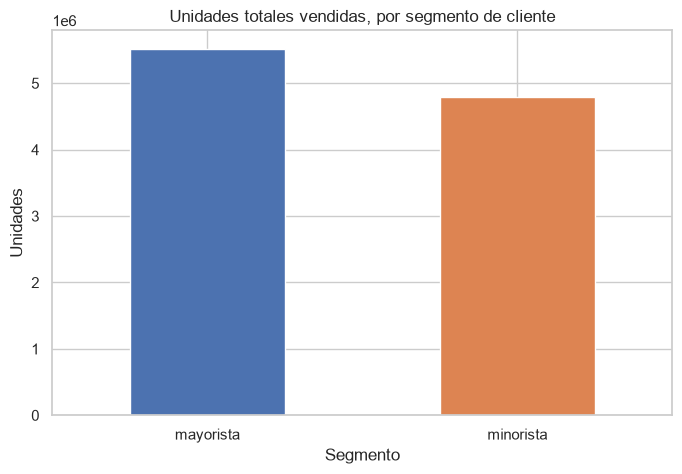

In [156]:
unidades_por_segmento = rfm.groupby('segmento')['quantity'].sum().sort_values(ascending=False)  # total de unidades, por segmento, de mayor a menor
print(unidades_por_segmento)

plt.figure(figsize=(8, 5))
unidades_por_segmento.plot(kind='bar', color=['#4C72B0', '#DD8452'])  # azul y naranja, paleta neutra
plt.title('Unidades totales vendidas, por segmento de cliente')
plt.xlabel('Segmento')
plt.ylabel('Unidades')
plt.xticks(rotation=0)  # nombres de segmento horizontales, no inclinados
plt.show()

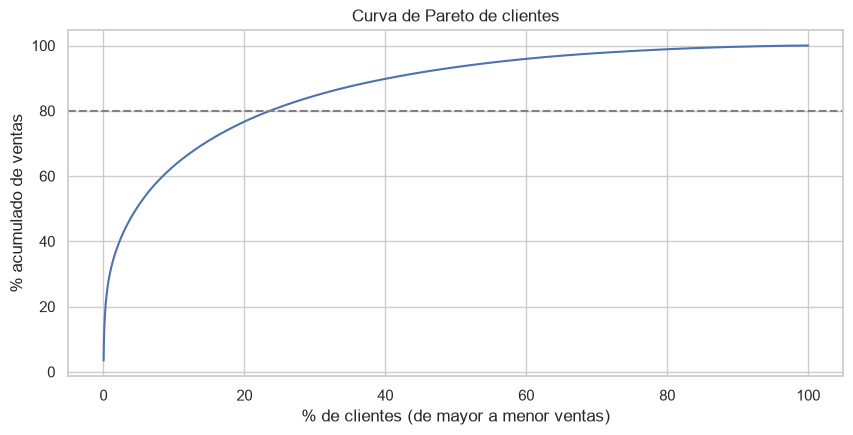

El 20% de clientes concentra 77% de las ventas


In [157]:
# Pareto: qué parte de los ingresos concentra cada fracción de clientes
v = cli["ventas"].sort_values(ascending=False).reset_index(drop=True)
acum = v.cumsum() / v.sum()
x = (np.arange(len(v)) + 1) / len(v)

fig, ax = plt.subplots()
ax.plot(x * 100, acum * 100)
ax.axhline(80, color="gray", ls="--")
ax.set_xlabel("% de clientes (de mayor a menor ventas)")
ax.set_ylabel("% acumulado de ventas")
ax.set_title("Curva de Pareto de clientes")
plt.show()
print(f"El 20% de clientes concentra {acum[int(len(v) * .2)]:.0%} de las ventas")

Clientes distintos: 5850
El 585 (10%) clientes que más gastan generan el 63.1% del ingreso total


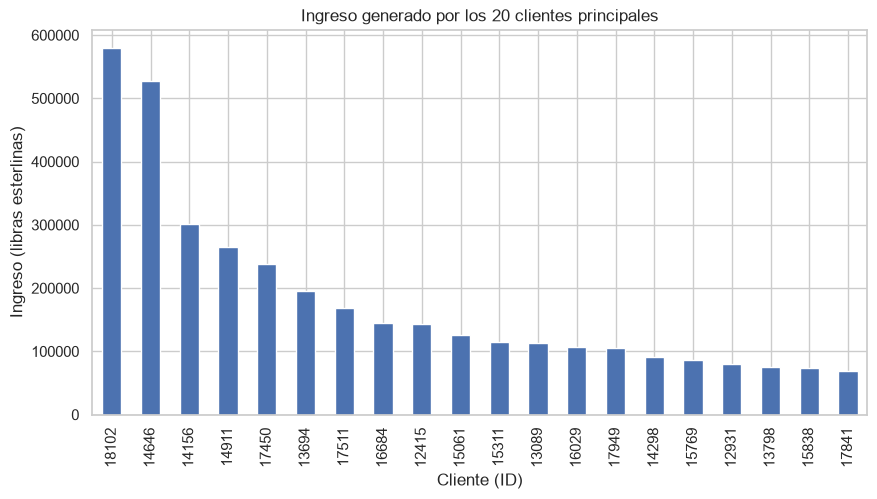

In [158]:
df_rfm_con_ingreso = rfm.copy()
df_rfm_con_ingreso['ingreso'] = df_rfm_con_ingreso['quantity'] * df_rfm_con_ingreso['unit_price']  # ingreso real por línea

ingreso_por_cliente = df_rfm_con_ingreso.groupby('customer_id')['ingreso'].sum().sort_values(ascending=False)
print(f"Clientes distintos: {len(ingreso_por_cliente)}")

# cuánto ingreso generan el 10% de clientes que más gastan
top_10_pct = int(len(ingreso_por_cliente) * 0.10)
ingreso_top_10_pct = ingreso_por_cliente.head(top_10_pct).sum()
ingreso_total = ingreso_por_cliente.sum()
print(f"El {top_10_pct} ({10}%) clientes que más gastan generan el {ingreso_top_10_pct/ingreso_total:.1%} del ingreso total")

plt.figure(figsize=(10, 5))
ingreso_por_cliente.head(20).plot(kind='bar', color='#4C72B0')  # top 20 clientes, para ver la forma de la caída
plt.title('Ingreso generado por los 20 clientes principales')
plt.xlabel('Cliente (ID)')
plt.ylabel('Ingreso (libras esterlinas)')
plt.xticks(rotation=90)
plt.show()

In [159]:
for porcentaje in [0.01, 0.05, 0.10, 0.20, 0.50]:
    n = int(len(ingreso_por_cliente) * porcentaje)
    ingreso = ingreso_por_cliente.head(n).sum()
    porcentaje_ingreso = ingreso / ingreso_total
    
    print(
        f"Top {porcentaje:.0%} de clientes "
        f"({n} clientes) → {porcentaje_ingreso:.1%} del ingreso"
    )

Top 1% de clientes (58 clientes) → 31.0% del ingreso
Top 5% de clientes (292 clientes) → 51.1% del ingreso
Top 10% de clientes (585 clientes) → 63.1% del ingreso
Top 20% de clientes (1170 clientes) → 76.7% del ingreso
Top 50% de clientes (2925 clientes) → 93.4% del ingreso


In [160]:
frecuencia_por_cliente = (
    rfm.groupby('customer_id')['invoice_no']
    .nunique()
)

print(frecuencia_por_cliente.describe())

count   5,850.00
mean        6.24
std        12.68
min         1.00
25%         1.00
50%         3.00
75%         7.00
max       371.00
Name: invoice_no, dtype: float64


In [161]:
cliente_resumen = (
    rfm.assign(
        ingreso=lambda x: x['quantity'] * x['unit_price']
    )
    .groupby('customer_id')
    .agg(
        ingreso_total=('ingreso', 'sum'),
        frecuencia=('invoice_no', 'nunique')
    )
    .sort_values('ingreso_total', ascending=False)
)

cliente_resumen.head(10)

,ingreso_total,frecuencia
customer_id,,
18102,"579,704.64",145
14646,"526,751.52",145
14156,"302,071.47",143
14911,"264,272.55",371
17450,"238,619.17",50
13694,"194,677.69",142
17511,"167,836.87",59
16684,"144,129.77",54
12415,"143,874.72",23


In [162]:
correlacion = cliente_resumen['ingreso_total'].corr(
    cliente_resumen['frecuencia']
)

print(f"Correlación entre ingreso y frecuencia: {correlacion:.3f}")

Correlación entre ingreso y frecuencia: 0.629


In [163]:
fecha_maxima = rfm['invoice_date'].max()

recencia_por_cliente = (
    rfm.groupby('customer_id')['invoice_date']
    .max()
    .apply(lambda fecha: (fecha_maxima - fecha).days)
)

print(f"Fecha máxima del dataset: {fecha_maxima}")
print(recencia_por_cliente.describe())

Fecha máxima del dataset: 2011-12-09 12:50:00
count   5,850.00
mean      199.16
std       208.43
min         0.00
25%        24.25
50%        94.00
75%       378.00
max       738.00
Name: invoice_date, dtype: float64


In [164]:
cliente_rfm = cliente_resumen.copy()

cliente_rfm['recencia'] = recencia_por_cliente

cliente_rfm.head(10)

,ingreso_total,frecuencia,recencia
customer_id,,,
18102,"579,704.64",145,0
14646,"526,751.52",145,1
14156,"302,071.47",143,9
14911,"264,272.55",371,0
17450,"238,619.17",50,7
13694,"194,677.69",142,3
17511,"167,836.87",59,2
16684,"144,129.77",54,3
12415,"143,874.72",23,23


In [165]:
cliente_rfm['R_score'] = pd.qcut(
    cliente_rfm['recencia'].rank(method='first'),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

cliente_rfm['F_score'] = pd.qcut(
    cliente_rfm['frecuencia'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

cliente_rfm['M_score'] = pd.qcut(
    cliente_rfm['ingreso_total'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

cliente_rfm['RFM_score'] = (
    cliente_rfm['R_score'].astype(str) +
    cliente_rfm['F_score'].astype(str) +
    cliente_rfm['M_score'].astype(str)
)

cliente_rfm.head(10)

,ingreso_total,frecuencia,recencia,R_score,F_score,M_score,RFM_score
customer_id,,,,,,,
18102,"579,704.64",145,0,5,5,5,555
14646,"526,751.52",145,1,5,5,5,555
14156,"302,071.47",143,9,5,5,5,555
14911,"264,272.55",371,0,5,5,5,555
17450,"238,619.17",50,7,5,5,5,555
13694,"194,677.69",142,3,5,5,5,555
17511,"167,836.87",59,2,5,5,5,555
16684,"144,129.77",54,3,5,5,5,555
12415,"143,874.72",23,23,4,5,5,455


In [166]:
# Resumen de los segmentos RFM principales
resumen_rfm = (
    cliente_rfm.groupby('RFM_score')
    .agg(
        clientes=('RFM_score', 'size'),
        ingreso_total=('ingreso_total', 'sum'),
        frecuencia_promedio=('frecuencia', 'mean'),
        recencia_promedio=('recencia', 'mean')
    )
    .sort_values('ingreso_total', ascending=False)
)

# Agregamos porcentajes
resumen_rfm['pct_clientes'] = (
    resumen_rfm['clientes'] / len(cliente_rfm) * 100
)

resumen_rfm['pct_ingreso'] = (
    resumen_rfm['ingreso_total'] / cliente_rfm['ingreso_total'].sum() * 100
)

# Mostrar los 15 segmentos que más ingresos generan
resumen_rfm.head(15).round(2)

,clientes,ingreso_total,frecuencia_promedio,recencia_promedio,pct_clientes,pct_ingreso
RFM_score,,,,,,
555,463,"7,966,733.30",28.61,6.83,7.91,47.60
455,242,"2,102,315.35",16.75,34.11,4.14,12.56
355,125,"843,744.55",14.08,96.20,2.14,5.04
255,32,"358,906.50",20.59,288.75,0.55,2.14
445,75,"356,442.34",6.69,35.23,1.28,2.13
345,59,"278,044.82",6.66,95.47,1.01,1.66
344,142,"278,041.79",6.04,105.72,2.43,1.66
545,53,"257,898.40",6.96,8.45,0.91,1.54
444,129,"250,098.28",6.09,35.36,2.21,1.49


In [167]:
clientes_alto_valor_inactivos = cliente_rfm[
    (cliente_rfm['R_score'] <= 2) &
    (cliente_rfm['M_score'] >= 4)
]

print("Cantidad de clientes:", len(clientes_alto_valor_inactivos))

print(
    "Porcentaje de clientes:",
    f"{len(clientes_alto_valor_inactivos) / len(cliente_rfm):.1%}"
)

print(
    "Ingreso histórico:",
    f"£{clientes_alto_valor_inactivos['ingreso_total'].sum():,.2f}"
)

print(
    "Porcentaje del ingreso histórico:",
    f"{clientes_alto_valor_inactivos['ingreso_total'].sum() / cliente_rfm['ingreso_total'].sum():.1%}"
)

Cantidad de clientes: 394
Porcentaje de clientes: 6.7%
Ingreso histórico: £1,317,654.26
Porcentaje del ingreso histórico: 7.9%


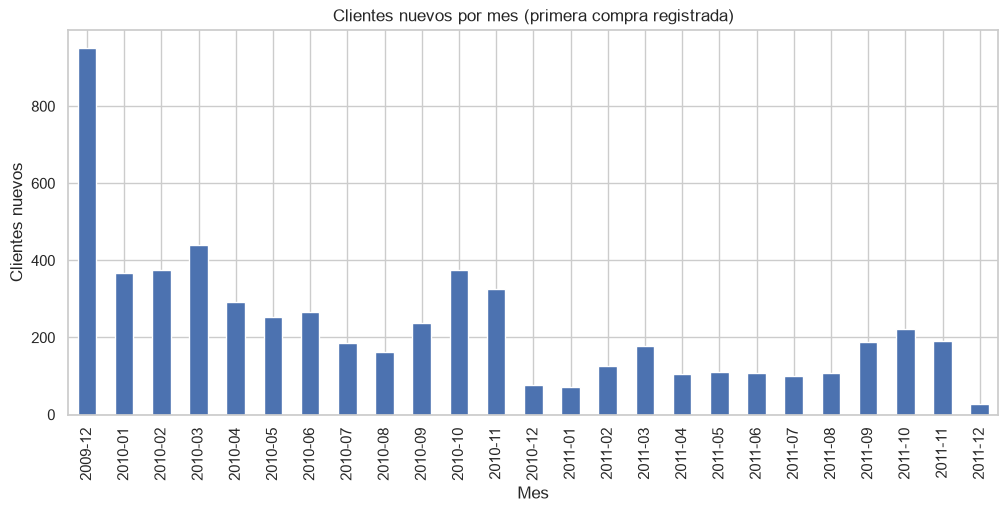

In [168]:
primera_compra_cliente = rfm.groupby('customer_id')['invoice_date'].min()
clientes_nuevos_por_mes = primera_compra_cliente.dt.to_period('M').value_counts().sort_index()

plt.figure(figsize=(12, 5))
clientes_nuevos_por_mes.plot(kind='bar', color='#4C72B0')
plt.title('Clientes nuevos por mes (primera compra registrada)')
plt.xlabel('Mes')
plt.ylabel('Clientes nuevos')
plt.xticks(rotation=90)
plt.show()

In [169]:
# Valores exactos de clientes nuevos en los meses mencionados
meses = pd.PeriodIndex(["2009-12", "2010-09", "2010-10", "2011-09", "2011-10"], freq="M")
clientes_nuevos_por_mes.reindex(meses)

2009-12    951
2010-09    238
2010-10    374
2011-09    188
2011-10    222
Freq: M, Name: count, dtype: int64

**Conclusión.**

**Concentración.** Hay 5.850 clientes. El 1% que más gasta (58 clientes) genera el 31,0% del ingreso; el 5%, el 51,1%; el 10%, el 63,1%; el 20%, el 76,7%; y la mitad de la base concentra el 93,4%.

**Alto volumen.** Los 293 clientes del segmento mayorista (5%) compraron 5.521.180 de las 10.317.863 unidades: **53,5% del volumen**. Generan £8,33 M contra £8,41 M de los 5.557 minoristas, es decir, casi la misma facturación con una fracción de los clientes. Su ingreso mediano por cliente es £14.070 contra £788, y emiten cerca del 29% de las facturas con cliente (10.455 de 36.480). Esto no significa que el 5% sean "definitivamente mayoristas", sino que un grupo chico concentra más de la mitad del volumen.

**Frecuencia.** La mitad de los clientes compró 3 veces o menos (el máximo es 371 compras). La correlación entre frecuencia e ingreso total es 0,629: en general, quien compra más seguido gasta más. Es correlación, no causalidad.

**RFM.** El segmento 555 reúne 463 clientes (7,91% de la base) y el 47,60% del ingreso histórico, con 28,6 compras promedio y 6,8 días de recencia promedio. Los segmentos 455 y 355 aportan juntos otro 17,6%, con recencia mayor (candidatos a fidelización). El segmento 255 (32 clientes) tiene frecuencia alta pero recencia de 289 días. Los segmentos se construyen con quintiles dentro de esta cartera, así que son posiciones relativas y no umbrales absolutos.

**Clientes en riesgo.** 394 clientes (6,7%) combinan alto valor histórico (£1.317.654, el 7,9% del ingreso) con baja recencia: son candidatos naturales de reactivación. No se puede afirmar que se hayan ido definitivamente, porque el dataset termina el 9/12/2011.

**Clientes nuevos.** Diciembre de 2009 muestra 951 "nuevos" por un artefacto: el dataset empieza ahí, así que todo cliente activo en ese mes aparece como nuevo. Tampoco la caída posterior debe leerse como una caída real de la captación, por la ventana limitada. Sí hay un patrón real: repuntes de septiembre-octubre en ambos años (238 y 374 clientes nuevos en septiembre y octubre de 2010; 188 y 222 en 2011), consistentes con clientes que empiezan a comprar antes de la temporada de fin de año.

## B.8 Mayoristas vs. minoristas: ¿cambia lo que parece "popular"?
Como el 5% de clientes de alto volumen mueve más de la mitad de las unidades, conviene medir cuánto cambian los rankings de productos según se los incluya o no. Se compara en tres métricas: unidades e ingresos (B.8.1), frecuencia en facturas, que es la métrica de popularidad que usa el equipo (B.8.2), y elegibilidad por compras de minoristas (B.8.3).

### B.8.1 Unidades e ingresos: todos contra solo minoristas

In [170]:

SEGMENTOS = ["minorista"]

def ranking(d):
    r = d.groupby("stock_code").agg(unidades=("quantity", "sum"), ventas=("ventas", "sum"))
    r["descripcion"] = desc
    r["pos_unidades"] = r["unidades"].rank(ascending=False, method="min")
    r["pos_ventas"] = r["ventas"].rank(ascending=False, method="min")
    return r

rank_todos = ranking(df)
rank_min = ranking(df[df["segmento"].isin(SEGMENTOS)])

print(f"Filas usadas: {df['segmento'].isin(SEGMENTOS).mean():.0%} del total")
print(f"Productos con ventas en el subconjunto: {len(rank_min)} de {len(rank_todos)}")

Filas usadas: 54% del total
Productos con ventas en el subconjunto: 4551 de 4725


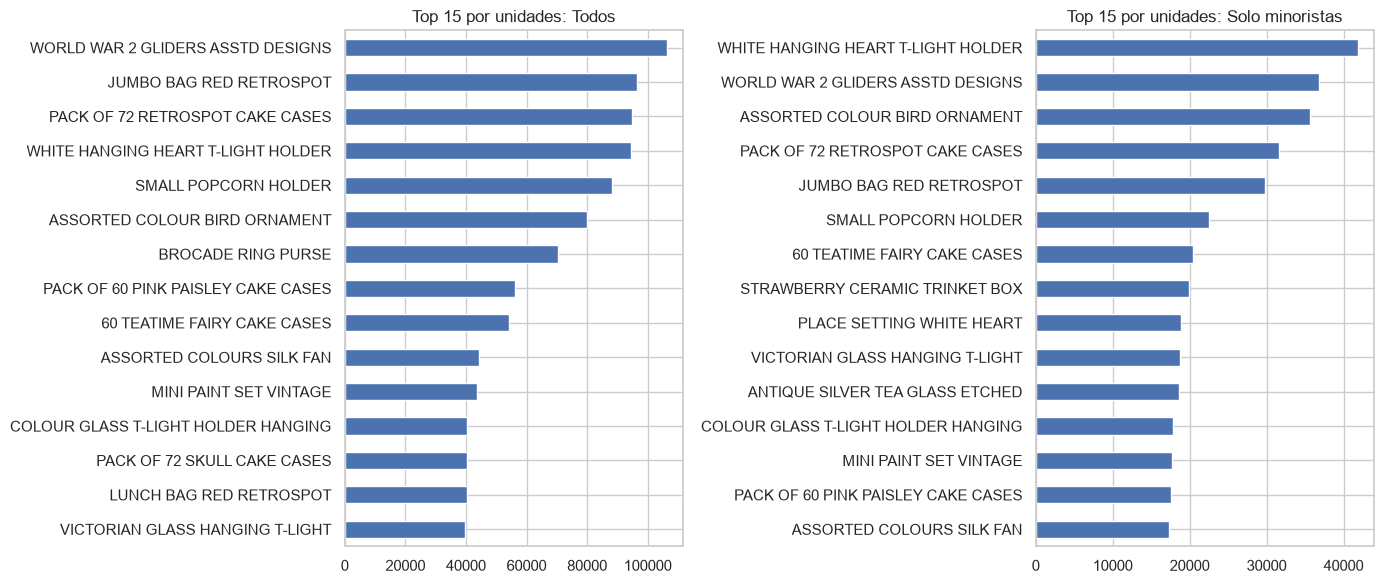

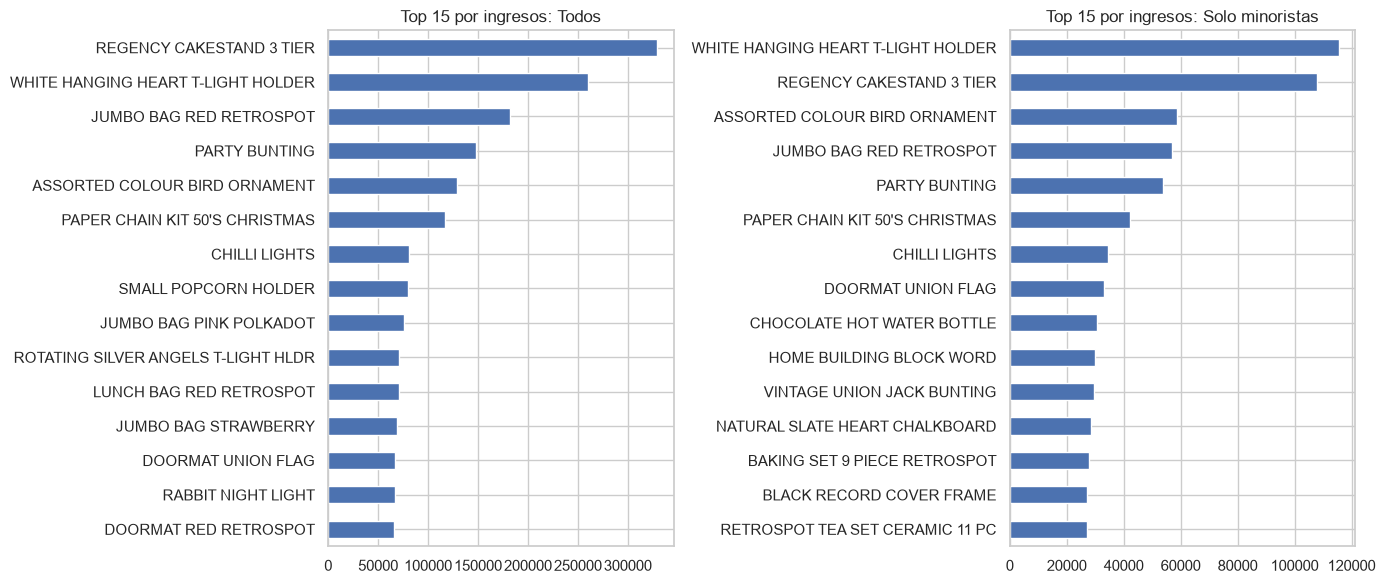

In [171]:
def comparar(col, titulo):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)
    for ax, (nombre, r) in zip(axes, [("Todos", rank_todos), ("Solo minoristas", rank_min)]):
        r.nlargest(15, col).set_index("descripcion")[col].sort_values().plot.barh(ax=ax, title=f"{titulo}: {nombre}")
        ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

comparar("unidades", "Top 15 por unidades")
comparar("ventas", "Top 15 por ingresos")

In [172]:
for col, pos in [("unidades", "pos_unidades"), ("ventas", "pos_ventas")]:
    top_t = set(rank_todos.nlargest(15, col).index)
    top_m = set(rank_min.nlargest(15, col).index)
    print(f"Top 15 por {col}: {len(top_t & top_m)} de 15 productos en común")

# Cómo se reubican los top 15 de minoristas respecto del ranking general
tabla = rank_min.nlargest(15, "unidades")[["descripcion", "unidades", "pos_unidades"]].rename(
    columns={"pos_unidades": "pos_minoristas"})
tabla["pos_general"] = rank_todos.loc[tabla.index, "pos_unidades"]
tabla["sube_o_baja"] = tabla["pos_general"] - tabla["pos_minoristas"]
tabla

Top 15 por unidades: 12 de 15 productos en común
Top 15 por ventas: 8 de 15 productos en común


,descripcion,unidades,pos_minoristas,pos_general,sube_o_baja
stock_code,,,,,
85123A,WHITE HANGING HEART T-LIGHT HOLDER,41865,1.00,4.00,3.00
84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,36801,2.00,1.00,-1.00
84879,ASSORTED COLOUR BIRD ORNAMENT,35683,3.00,6.00,3.00
21212,PACK OF 72 RETROSPOT CAKE CASES,31665,4.00,3.00,-1.00
85099B,JUMBO BAG RED RETROSPOT,29851,5.00,2.00,-3.00
22197,SMALL POPCORN HOLDER,22547,6.00,5.00,-1.00
84991,60 TEATIME FAIRY CAKE CASES,20404,7.00,9.00,2.00
21232,STRAWBERRY CERAMIC TRINKET BOX,19854,8.00,19.00,11.00
22151,PLACE SETTING WHITE HEART,18869,9.00,41.00,32.00


In [173]:
rank_min2 = ranking(df[df["segmento"].isin(["minorista", "sin_cliente"])])

for col in ["unidades", "ventas"]:
    t_todos = set(rank_todos.nlargest(15, col).index)
    t_min = set(rank_min.nlargest(15, col).index)
    t_min2 = set(rank_min2.nlargest(15, col).index)
    print(f"Top 15 por {col}:")
    print(f"  minoristas + sin_cliente vs solo minoristas: {len(t_min2 & t_min)} de 15 en común")
    print(f"  minoristas + sin_cliente vs todos:           {len(t_min2 & t_todos)} de 15 en común")

Top 15 por unidades:
  minoristas + sin_cliente vs solo minoristas: 12 de 15 en común
  minoristas + sin_cliente vs todos:           9 de 15 en común
Top 15 por ventas:
  minoristas + sin_cliente vs solo minoristas: 10 de 15 en común
  minoristas + sin_cliente vs todos:           10 de 15 en común


**Conclusión.** Excluir a los mayoristas cambia el top 15 de ambos rankings, en distinta medida. Solo con minoristas, coinciden 12 de 15 productos por unidades y 8 de 15 por ingresos: el Regency Cakestand pasa del primer al segundo lugar y aparecen productos de perfil más de regalo (por ejemplo, Chocolate Hot Water Bottle, Home Building Block Word, Natural Slate Heart Chalkboard). Al sumar las ventas sin cliente, la coincidencia con el ranking general baja a 9 de 15 por unidades y es de 10 de 15 por ingresos, de modo que el resultado depende de cómo se traten esas ventas (23% de las filas, sin clasificar). Pendiente de definir con el equipo: qué hacer con los mayoristas y con las ventas sin cliente.

Nota: la métrica de popularidad que usa el equipo es la frecuencia en facturas, no las unidades ni los ingresos; se analiza a continuación.

### B.8.2 Popularidad por frecuencia en facturas
El equipo definió la popularidad de un producto como **en cuántas facturas distintas aparece**, sin importar la cantidad, para que las compras de miles de unidades no inflen el ranking. Se compara el top 15 en cuatro variantes: todos, sin facturas bulk (lo que el equipo ya prueba), solo minoristas, y minoristas sin bulk.

In [174]:
def ranking_frecuencia(d):
    r = d.groupby("stock_code")["invoice_no"].nunique().rename("facturas").to_frame()
    r["descripcion"] = desc
    return r

variantes = {
    "todos": df,
    "sin_bulk": df[~df["factura_bulk"]],
    "solo_minoristas": df[df["segmento"] == "minorista"],
    "minoristas_sin_bulk": df[(df["segmento"] == "minorista") & ~df["factura_bulk"]],
}
tops = {k: set(ranking_frecuencia(v).nlargest(15, "facturas").index) for k, v in variantes.items()}

for k, t in tops.items():
    print(f"{k:22s} {len(t & tops['todos'])} de 15 en común con 'todos'")

todos                  15 de 15 en común con 'todos'
sin_bulk               15 de 15 en común con 'todos'
solo_minoristas        7 de 15 en común con 'todos'
minoristas_sin_bulk    9 de 15 en común con 'todos'


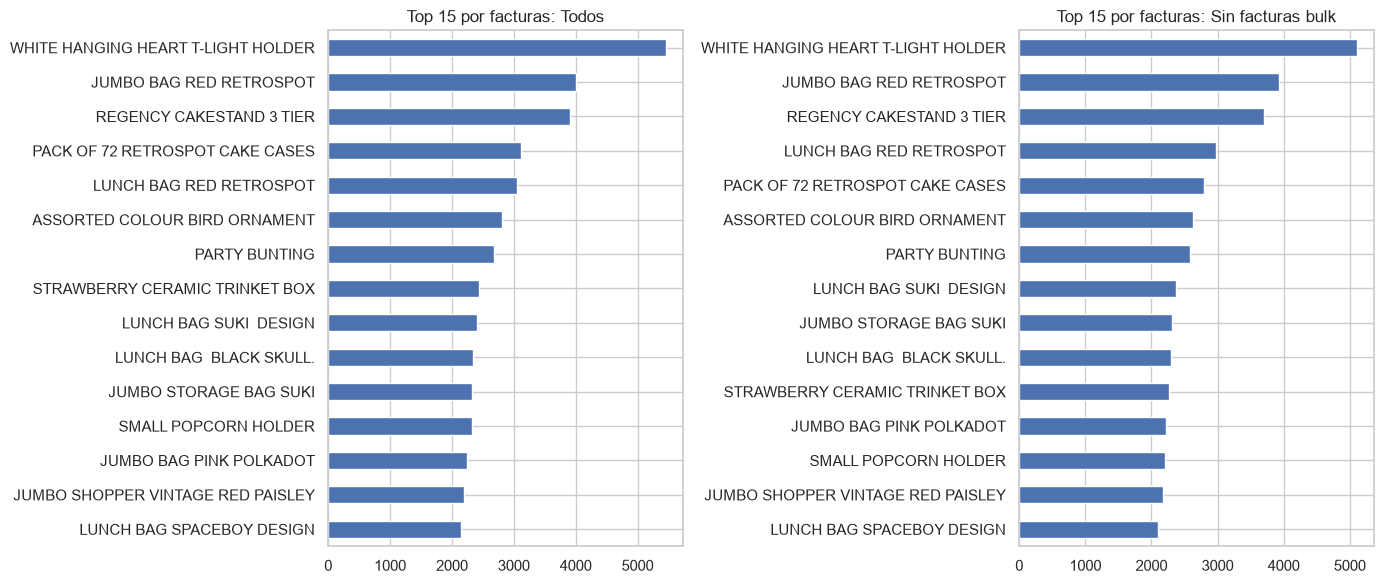

In [175]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (nombre, d) in zip(axes, [("Todos", df), ("Sin facturas bulk", variantes["sin_bulk"])]):
    ranking_frecuencia(d).nlargest(15, "facturas").set_index("descripcion")["facturas"] \
        .sort_values().plot.barh(ax=ax, title=f"Top 15 por facturas: {nombre}")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [176]:
f = {k: ranking_frecuencia(v)["facturas"] for k, v in variantes.items()}
print(pd.DataFrame(f).fillna(0).corr(method="spearman").round(3))

                     todos  sin_bulk  solo_minoristas  minoristas_sin_bulk
todos                 1.00      1.00             0.97                 0.97
sin_bulk              1.00      1.00             0.97                 0.97
solo_minoristas       0.97      0.97             1.00                 1.00
minoristas_sin_bulk   0.97      0.97             1.00                 1.00


In [177]:
r_todos = ranking_frecuencia(df)
pos_todos = r_todos["facturas"].rank(ascending=False, method="min")
r_min = ranking_frecuencia(variantes["solo_minoristas"])
pos_min = r_min["facturas"].rank(ascending=False, method="min")

t = r_min.nlargest(15, "facturas").assign(pos_minoristas=pos_min, pos_todos=pos_todos)
t[["descripcion", "facturas", "pos_minoristas", "pos_todos"]]

,descripcion,facturas,pos_minoristas,pos_todos
stock_code,,,,
85123A,WHITE HANGING HEART T-LIGHT HOLDER,3607,1.00,1.00
22423,REGENCY CAKESTAND 3 TIER,2213,2.00,3.00
85099B,JUMBO BAG RED RETROSPOT,2077,3.00,2.00
84879,ASSORTED COLOUR BIRD ORNAMENT,2005,4.00,6.00
21212,PACK OF 72 RETROSPOT CAKE CASES,1607,5.00,4.00
20725,LUNCH BAG RED RETROSPOT,1581,6.00,5.00
21034,REX CASH+CARRY JUMBO SHOPPER,1536,7.00,33.00
22470,HEART OF WICKER LARGE,1466,8.00,30.00
22469,HEART OF WICKER SMALL,1441,9.00,16.00


**Conclusión.** Medida por frecuencia en facturas, excluir las facturas bulk no cambia el top 15 (15 de 15 productos en común, correlación de rangos de 1,00). Considerar solo minoristas sí lo cambia (7 de 15 en común; 9 de 15 si además se excluye el bulk), pero el ranking completo es casi igual (correlación de Spearman 0,97) y los 8 productos que entran al top de minoristas ya estaban entre los puestos 16 y 33 del ranking general: es un reordenamiento en el borde del top 15, no un cambio de fondo. Los mayoristas son el 5% de los clientes pero emiten cerca del 29% de las facturas con cliente.

Además, el top por frecuencia está dominado por artículos de uso cotidiano: 8 de los 15 primeros son bolsas (Lunch Bag, Jumbo Bag). Habrá que tenerlo en cuenta para un asistente de regalos al combinarlo con las categorías (B.9).

### B.8.3 Elegibilidad: recomendar solo productos con suficientes compradores minoristas
Idea planteada en el equipo: mantener todas las transacciones para entrenar el modelo, pero que solo pueda **recomendar** productos comprados por al menos X clientes minoristas distintos. Acá se mide qué parte del catálogo y de las ventas queda cubierta según X.

In [178]:
min_df = df[df["segmento"] == "minorista"]
clientes_min = min_df.groupby("stock_code")["customer_id"].nunique().rename("clientes_minoristas")

cat = (df.groupby("stock_code").agg(unidades=("quantity", "sum"), ventas=("ventas", "sum"))
         .join(clientes_min).fillna({"clientes_minoristas": 0}))
cat["descripcion"] = desc

filas = []
for x in [1, 3, 5, 10, 20, 50]:
    ok = cat["clientes_minoristas"] >= x
    filas.append({"X": x, "productos_elegibles": int(ok.sum()),
                  "pct_catalogo": ok.mean(),
                  "pct_ventas_cubiertas": cat.loc[ok, "ventas"].sum() / cat["ventas"].sum()})
pd.DataFrame(filas).round(3)

,X,productos_elegibles,pct_catalogo,pct_ventas_cubiertas
0,1,4551,0.96,1.00
1,3,4293,0.91,1.00
2,5,4092,0.87,0.99
3,10,3644,0.77,0.99
4,20,3055,0.65,0.97
5,50,2128,0.45,0.91


In [179]:
# Productos con muchas ventas pero pocos clientes minoristas distintos (los que quedarían fuera)
X = 10
cat[cat["clientes_minoristas"] < X].nlargest(15, "ventas")[["descripcion", "unidades", "ventas", "clientes_minoristas"]]

,descripcion,unidades,ventas,clientes_minoristas
stock_code,,,,
85220,SMALL FAIRY CAKE FRIDGE MAGNETS,12236,"6,875.00",1.00
22833,HALL CABINET WITH 3 DRAWERS,120,"4,163.54",6.00
22790,"MIRROR, ARCHED GEORGIAN",200,"3,884.00",0.00
22830,UTILTY CABINET WITH HOOKS,181,"3,760.71",9.00
20786,BLACK RETRO BAR STOOL,99,"3,533.90",8.00
20784,RED RETRO BAR STOOL,100,"3,530.92",3.00
84872A,TEATIME FUNKY FLOWER BACKPACK FOR 2,235,"2,620.01",4.00
22828,REGENCY MIRROR WITH SHUTTERS,17,"2,565.00",9.00
20787,BLUE RETRO BAR STOOL,69,"2,535.10",4.00


In [180]:
cat.loc["PADS", ["unidades", "ventas", "clientes_minoristas"]]

unidades                 17
ventas                 0.02
clientes_minoristas   12.00
Name: PADS, dtype: object

**Conclusión.** Exigir un mínimo de X clientes minoristas distintos reduce el catálogo recomendable mucho más de lo que reduce las ventas cubiertas (ventas totales): con X = 10 quedan 3.644 de 4.725 productos (77%) que cubren el 99% de las ventas; con X = 20, 3.055 (65%) y 97%; con X = 50, 2.128 (45%) y 91%. Los productos que se excluyen son, en su mayoría, de cola larga.

Entre los excluidos con X = 10 hay dos tipos. Por un lado, productos que dependen de pocos compradores por volumen (por ejemplo SMALL FAIRY CAKE FRIDGE MAGNETS: 12.236 unidades y 1 solo cliente minorista). Por otro, artículos caros de poco volumen (gabinetes, espejos y taburetes, de 15 a 200 unidades), que probablemente se excluirían por tener pocos compradores y no por ser mayoristas. El umbral X mezcla ambas cosas. El caso PADS (A.6.1) muestra la situación inversa: lo compraron 12 clientes minoristas, así que pasa el filtro con X = 10 aunque casi no tiene precio.

Pendiente: elegir X con el equipo y evaluar un criterio complementario, como el porcentaje de unidades compradas por mayoristas.

## B.9 Categorías de producto
Ingeniería de Datos armó 28 categorías (TF-IDF y K-Means sobre la descripción). Para un asistente de regalos, la categoría permite pasar de "qué producto compra" a "qué tipo de regalo suele interesar". Se unen por `stock_code`, no por descripción (ver A.8).

In [181]:
catalogo = pd.read_parquet('../data/processed/catalogo_categorizado.parquet')
print(catalogo.shape)
print(catalogo['categoria'].nunique(), "categorías")

# Uno cada venta con su categoría (por stock_code, no por description — ver Sección A.7)
df_con_categoria = df.merge(catalogo[['stock_code', 'categoria']], on='stock_code', how='left')
print("\nVentas sin categoría asignada:", df_con_categoria['categoria'].isna().sum())

(4725, 6)
28 categorías

Ventas sin categoría asignada: 0


In [182]:
resumen_categoria = (
    df_con_categoria
    .assign(ingreso=lambda x: x['quantity'] * x['unit_price'])
    .groupby('categoria')
    .agg(
        unidades=('quantity', 'sum'),
        ingreso=('ingreso', 'sum'),
        productos_distintos=('stock_code', 'nunique'),
        precio_medio=('unit_price', 'mean'),
        clientes=('customer_id', 'nunique'),
    )
    .sort_values('ingreso', ascending=False)
)
resumen_categoria.round(2)

,unidades,ingreso,productos_distintos,precio_medio,clientes
categoria,,,,,
Variedad / Sorpresa,2880526,"5,024,784.94",1258,3.74,5528
Estampado retrospot y lunares,989899,"1,800,108.82",192,3.43,4512
"Sets y combos (papelería, luces, velas)",784697,"1,711,520.29",362,3.90,4666
Bolsas de regalo y contenedores chicos,884514,"1,548,953.19",150,2.44,3575
Decoración de árbol navideño,723689,"1,072,658.44",392,2.72,4503
Iluminación y portavelas colgantes,668432,"994,185.22",119,2.19,3661
Corazones decorativos,587889,"942,772.61",221,2.36,4034
Cuadernos y cajas vintage,449914,"932,836.95",197,4.43,3982
Diseños y accesorios variados,608756,"912,422.20",325,2.70,4293


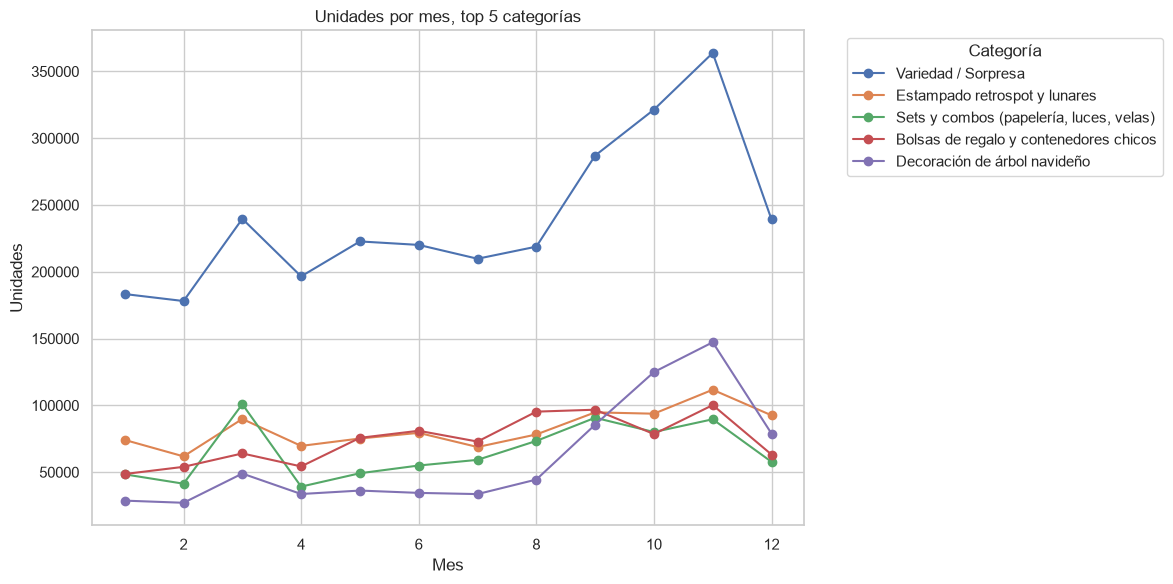

In [183]:
ventas_categoria_mes = (
    df_con_categoria
    .assign(mes=df_con_categoria['invoice_date'].dt.month)
    .groupby(['categoria', 'mes'])['quantity']
    .sum()
    .unstack(fill_value=0)
)

# Top 5 categorías por volumen total, para no mostrar las 28 en el gráfico
top5_categorias = resumen_categoria.head(5).index
ventas_categoria_mes.loc[top5_categorias].T.plot(figsize=(12, 6), marker='o')
plt.title('Unidades por mes, top 5 categorías')
plt.xlabel('Mes')
plt.ylabel('Unidades')
plt.legend(title='Categoría', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [184]:
# Valores exactos de unidades por mes (suma de ambos años) en la categoría navideña
ventas_categoria_mes.loc["Decoración de árbol navideño"]

mes
1      28689
2      27079
3      48954
4      33647
5      36222
6      34482
7      33586
8      44465
9      85538
10    124920
11    147240
12     78867
Name: Decoración de árbol navideño, dtype: int64

In [185]:
top_paises = df_con_categoria['country_std'].value_counts().head(5).index
categoria_pais = (
    df_con_categoria[df_con_categoria['country_std'].isin(top_paises)]
    .groupby(['country_std', 'categoria'])['quantity']
    .sum()
    .reset_index()
)
# Para cada país, su categoría más vendida
top_categoria_por_pais = categoria_pais.loc[categoria_pais.groupby('country_std')['quantity'].idxmax()]
print(top_categoria_por_pais.sort_values('quantity', ascending=False).to_string(index=False))

   country_std           categoria  quantity
United Kingdom Variedad / Sorpresa   2340171
        France Variedad / Sorpresa     72545
       Ireland Variedad / Sorpresa     72524
   Netherlands Variedad / Sorpresa     71258
       Germany Variedad / Sorpresa     67087


**Conclusión.**

- **"Variedad / Sorpresa" es una categoría comodín:** reúne 1.258 productos (26,6% del catálogo), 2.880.526 unidades y £5,02 M, y domina en volumen, ingreso, productos y clientes. Esto es esperable por su tamaño, pero limita su utilidad para recomendar. Le siguen, por ingreso, "Estampado retrospot y lunares" (£1,80 M), "Sets y combos" (£1,71 M) y "Bolsas de regalo y contenedores chicos" (£1,55 M).
- **Estacionalidad por categoría:** "Decoración de árbol navideño" (392 productos, £1,07 M) tiene el salto más marcado. Pasa de entre 27.079 y 48.954 unidades por mes entre enero y agosto (suma de ambos años) a 147.240 en noviembre; la suba ya se nota en septiembre (85.538) y octubre (124.920), y baja en diciembre (78.867). "Variedad / Sorpresa" sube mucho menos en términos relativos. Para el asistente, esto sugiere priorizar la categoría navideña desde septiembre-octubre y no tratar todas las categorías por igual durante el año.
- **Categoría por país:** en los cinco países con más líneas de venta, "Variedad / Sorpresa" es la categoría principal. Este corte no permite detectar diferencias de gusto entre mercados, porque la categoría genérica es demasiado grande. No debe leerse como que todos los países tienen los mismos gustos.
- **Limitación:** algunas categorías describen un estilo (por ejemplo, "Estampado retrospot y lunares") más que una intención de regalo. Refinar "Variedad / Sorpresa" mejoraría mucho el aporte de las categorías.

## B.10 Productos comprados juntos
Primer vistazo exploratorio de qué se compra junto con qué, la pregunta que más le sirve a un sistema de recomendación. **No reemplaza el modelo colaborativo** que arma el equipo de modelado: es un chequeo rápido para confirmar que el dataset tiene señal. Se analizan solo facturas con entre 2 y 15 productos distintos, porque las facturas muy grandes generarían millones de pares sin aportar señal (el filtro es por tamaño de factura, no por `factura_bulk`).

In [186]:
from itertools import combinations
from collections import Counter

# Para no tardar una eternidad, trabajamos sobre una muestra de facturas con pocos productos
# (las facturas bulk, con cientos de productos, generarían millones de pares sin aportar señal real)
facturas_chicas = df.groupby('invoice_no')['stock_code'].nunique()
facturas_para_analizar = facturas_chicas[(facturas_chicas >= 2) & (facturas_chicas <= 15)].index

pares_contador = Counter()
for _, productos_factura in df[df['invoice_no'].isin(facturas_para_analizar)].groupby('invoice_no')['stock_code']:
    productos_unicos = sorted(set(productos_factura))
    for par in combinations(productos_unicos, 2):
        pares_contador[par] += 1

pares_top = pd.DataFrame(pares_contador.most_common(20), columns=['par', 'veces_juntos'])
pares_top['producto_1'] = pares_top['par'].apply(lambda x: x[0])
pares_top['producto_2'] = pares_top['par'].apply(lambda x: x[1])

# Le pegamos la descripción real a cada código, para que se entienda qué es cada par
desc_por_codigo = catalogo.set_index('stock_code')['description']
pares_top['descripcion_1'] = pares_top['producto_1'].map(desc_por_codigo)
pares_top['descripcion_2'] = pares_top['producto_2'].map(desc_por_codigo)

print(pares_top[['descripcion_1', 'descripcion_2', 'veces_juntos']].to_string(index=False))

                    descripcion_1                      descripcion_2  veces_juntos
          JUMBO BAG RED RETROSPOT               JUMBO BAG STRAWBERRY           227
 RED HANGING HEART T-LIGHT HOLDER WHITE HANGING HEART T-LIGHT HOLDER           218
          JUMBO BAG PINK POLKADOT            JUMBO BAG RED RETROSPOT           213
  GREEN REGENCY TEACUP AND SAUCER    ROSES REGENCY TEACUP AND SAUCER           200
          JUMBO BAG RED RETROSPOT     JUMBO  BAG BAROQUE BLACK WHITE           192
            HEART OF WICKER SMALL              HEART OF WICKER LARGE           180
  GREEN REGENCY TEACUP AND SAUCER     PINK REGENCY TEACUP AND SAUCER           174
   PINK REGENCY TEACUP AND SAUCER    ROSES REGENCY TEACUP AND SAUCER           162
WOODEN PICTURE FRAME WHITE FINISH         WOODEN FRAME ANTIQUE WHITE           161
       ALARM CLOCK BAKELIKE GREEN           ALARM CLOCK BAKELIKE RED           161
           JUMBO STORAGE BAG SUKI            JUMBO BAG RED RETROSPOT           159
    

**Conclusión.** Los pares más frecuentes no son ruido: la gente suele comprar **variantes del mismo producto o de una misma línea** en la misma compra. Por ejemplo, distintas bolsas Jumbo (la Red Retrospot aparece junto a varios estampados distintos), las tazas Regency en varios colores, los portavelas de corazón rojo y blanco, los relojes Bakelite verde y rojo, o HEART OF WICKER small y large. El par más repetido (JUMBO BAG RED RETROSPOT con JUMBO BAG STRAWBERRY) aparece 227 veces.

**Implicancia:** una primera regla de recomendación simple y respaldada por los datos es ofrecer, cuando alguien elige un producto, otras variantes de color o diseño del mismo producto antes que productos de categorías totalmente distintas. Esto es una señal exploratoria y potencial variable para el modelo, no un resultado del modelo.

# PARTE C — Qué significa para el asistente de regalos

## C.1 Conclusiones que el equipo puede usar

1. **La temporada importa.** Noviembre es el mes más fuerte en unidades e ingresos en los dos años, y la subida arranca en septiembre. La categoría navideña es la que más se concentra en esa ventana. Las recomendaciones pueden incorporar el contexto temporal.
2. **La categoría ayuda, pero hay que refinarla.** Permite pasar del producto a la intención, pero "Variedad / Sorpresa" es el 26,6% del catálogo y diluye el análisis.
3. **Las variantes son una señal fuerte.** Los productos de una misma línea, color o estampado se compran juntos.
4. **La popularidad depende de cómo se mida.** Unidades, ingresos y frecuencia en facturas dan rankings distintos. Con la métrica del equipo (frecuencia), excluir las facturas bulk no cambia el top 15, y excluir mayoristas lo mueve pero dentro de los primeros 33 puestos.
5. **El alto volumen puede sesgar las recomendaciones.** El 5% de los clientes mueve el 53,5% de las unidades. Una opción respaldada por los datos es entrenar con todas las transacciones y limitar lo que se **recomienda** a productos con un mínimo de clientes minoristas (con X = 10: 77% del catálogo y 99% de las ventas). El umbral falta elegirlo.
6. **El comportamiento del cliente aporta información adicional.** RFM distingue clientes de alto valor, frecuentes, recientes y de alto valor inactivos; puede complementar las señales producto-producto.
7. **Producto = `stock_code`.** Es una decisión metodológica que debe mantenerse en el modelado.

## C.2 Pendientes y próximos pasos

- **Decidir qué hacer con los mayoristas y con las ventas sin cliente** en el entrenamiento y en la recomendación, y elegir el umbral X.
- **Decidir si `es_ajuste_precio` se excluye en modelado** o se incorpora a `clean.py` como columna.
- **Revisar el criterio de `factura_bulk`** o documentarlo como límite conocido.
- **Confirmar las facturas 518505 y 524174** (mismas unidades, productos e ingreso).
- **Definir un precio mínimo para recomendar** (caso PADS).
- **Usar `country_std` en Power BI** y marcarla como categoría de datos *País o región*.
- **Análisis de presupuesto:** el asistente recomienda dentro de un presupuesto; falta ver cuántos productos y combos entran en rangos de £20, £50 y £100, por categoría.
- **Estacionalidad por producto y combos por categoría.**
- **Refinar la categoría "Variedad / Sorpresa".**
- **Completar la reconciliación del ETL** con unidades e ingreso del Excel crudo (opcional).